# Elektrostatika: Dari Hukum Coulomb hingga Persamaan Laplace dan Bahan Dielektrik
**Mata Kuliah:** Elektrodinamika Klasik (Program Magister Fisika, Universitas Padjadjaran)  
**Topik Pokok:** Gaya Listrik (Hukum Coulomb), Medan Listrik (Hukum Gauss), Potensial Listrik & Energi Potensial (Persamaan Laplace), Syarat Batas (Metode Keunikan dan Separasi Variabel), dan Kapasitansi Dielektrik.  
**Metodologi Komputasi:** Penurunan Analitik Matematis, Verifikasi Simbolik (SymPy), Visualisasi Geometris 2D (Matplotlib), dan Pemodelan 3D Fotorealistik (PyVista).

---

## 1. Pendahuluan: Kerangka Teori Elektrostatika

Elektrostatika merupakan cabang elektrodinamika klasik yang mengkaji fenomena medan listrik statik $\mathbf{E}$ yang bersumber dari **distribusi muatan listrik yang diam terhadap waktu** (*stationary charges*):
$$\frac{\partial \rho}{\partial t} = 0, \quad \mathbf{J} = \mathbf{0}$$

Secara fundamental, interaksi elektrostatik di ruang hampa diatur oleh dua persamaan Maxwell elektrostatika:
1. **Hukum Gauss (Bentuk Diferensial):**
   $$\nabla \cdot \mathbf{E} = \frac{\rho}{\epsilon_0}$$
   Fluks medan listrik yang menembus sembarang permukaan tertutup sebanding dengan total muatan listrik yang dilingkupi oleh permukaan tersebut.
2. **Sifat Konservatif Medan Elektrostatik:**
   $$\nabla \times \mathbf{E} = \mathbf{0} \iff \oint_C \mathbf{E} \cdot d\mathbf{l} = 0$$
   Curl medan listrik statik selalu lenyap, yang mengimplikasikan bahwa medan elektrostatik dapat direpresentasikan secara eksak sebagai gradien dari suatu fungsi potensial skalar $V(\mathbf{r})$:
   $$\mathbf{E}(\mathbf{r}) = -\nabla V(\mathbf{r})$$

Substitusi hubungan potensial ke dalam Hukum Gauss menghasilkan **Persamaan Poisson**:
$$\nabla \cdot (-\nabla V) = \frac{\rho}{\epsilon_0} \implies \nabla^2 V = -\frac{\rho}{\epsilon_0}$$

Pada ruang yang bebas muatan lokal ($\rho = 0$), persamaan ini tereduksi menjadi **Persamaan Laplace**:
$$\nabla^2 V = 0$$

### 1.2 Prinsip Superposisi Linear: Fondasi Universal Elektrostatika
Karena operator divergensi $\nabla \cdot$, gradien $\nabla$, dan Laplacian $\nabla^2$ adalah operator diferensial linear, persamaan dasar elektrostatika mematuhi **Prinsip Superposisi Linear**:
$$\nabla \cdot (\mathbf{E}_1 + \mathbf{E}_2) = \nabla \cdot \mathbf{E}_1 + \nabla \cdot \mathbf{E}_2 = \frac{\rho_1 + \rho_2}{\epsilon_0}$$
$$\nabla^2 (V_1 + V_2) = \nabla^2 V_1 + \nabla^2 V_2 = -\frac{\rho_1 + \rho_2}{\epsilon_0}$$

Konsekuensinya, jika sebuah sistem terdiri dari distribusi muatan total $\rho(\mathbf{r}) = \sum_i \rho_i(\mathbf{r})$, maka medan listrik dan potensial total di setiap titik di ruang merupakan penjumlahan linear murni dari kontribusi masing-masing komponen sumber:
$$\mathbf{E}(\mathbf{r}) = \sum_{i=1}^N \mathbf{E}_i(\mathbf{r}), \quad V(\mathbf{r}) = \sum_{i=1}^N V_i(\mathbf{r})$$

Pada notebook komputasi ini, **lima pilar materi elektrostatika fundamental** dikupas secara tuntas:
1. **Gaya Listrik (Hukum Coulomb):** Interaksi muatan titik & kontinu serta superposisi gaya vektor.
2. **Medan Listrik (Hukum Gauss):** Fluks medan, simetri sferis, dan superposisi medan/fluks pada problem rongga (*cavity problem*).
3. **Potensial Listrik & Energi Potensial (Persamaan Laplace):** Integrasi garis medan, hubungan $\mathbf{E} = -\nabla V$, superposisi skalar potensial vs non-linearitas energi elektrostatik ($W_{12} = \epsilon_0 \int \mathbf{E}_1 \cdot \mathbf{E}_2 d\tau$).
4. **Syarat Batas (Metode Keunikan dan Separasi Variabel):** Diskontinuitas komponen normal medan di antarmuka, pembuktian Teorema Keunikan (Dirichlet/Neumann), penyelesaian analitik Persamaan Laplace via Metode Separasi Variabel koordinat Kartesian (deret Fourier ortogonal), dan superposisi solusi basis.
5. **Kapasitansi dan Bahan Dielektrik:** Polarisasi makroskopis $\mathbf{P}$, muatan terikat $\rho_b$ dan $\sigma_b$, medan pergeseran listrik $\mathbf{D} = \epsilon \mathbf{E}$, dan superposisi medan bebas/terikat serta kapasitor majemuk.


In [1]:
# Verifikasi ketersediaan pustaka ilmiah komputasi saintifik
import sys
import numpy as np
import sympy as sp
import matplotlib
import pyvista as pv

print(f"Python Environment     : Python {sys.version.split()[0]}")
print(f"NumPy (Komputasi Vektor): v{np.__version__}")
print(f"SymPy (Analisis Simbol) : v{sp.__version__}")
print(f"Matplotlib (Plot 2D)    : v{matplotlib.__version__}")
print(f"PyVista (Render 3D PBR) : v{pv.__version__}")


Python Environment     : Python 3.14.7
NumPy (Komputasi Vektor): v2.5.2
SymPy (Analisis Simbol) : v1.14.0
Matplotlib (Plot 2D)    : v3.11.1
PyVista (Render 3D PBR) : v0.49.0


In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pyvista as pv

# Konstanta Fundamental Fisika (SI)
EPSILON_0 = 8.8541878128e-12  # Permitivitas vakum (F/m atau C^2 / (N.m^2))
K_E = 1.0 / (4.0 * np.pi * EPSILON_0)  # Konstanta Coulomb ~ 8.98755e9 N.m^2/C^2

# Konfigurasi Rendering PyVista
pv.set_jupyter_backend('static')
pv.global_theme.background = '#0b1120'  # Deep slate dark
pv.global_theme.font.color = '#f8fafc'
pv.global_theme.font.family = 'arial'
pv.global_theme.anti_aliasing = 'msaa'

# Konfigurasi Plot 2D Matplotlib
plt.rcParams.update({
    'figure.facecolor': '#0b1120',
    'axes.facecolor': '#1e293b',
    'axes.edgecolor': '#475569',
    'axes.labelcolor': '#f8fafc',
    'xtick.color': '#94a3b8',
    'ytick.color': '#94a3b8',
    'text.color': '#f8fafc',
    'grid.color': '#334155',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'font.size': 10
})

def init_pyvista_plotter(title="Visualisasi PyVista", window_size=(900, 560)):
    """Inisialisasi Plotter PyVista dengan pencahayaan sinematik dan latar belakang elegan."""
    p = pv.Plotter(window_size=window_size)
    p.set_background('#0b1120', top='#1e293b')  # Gradien vertikal elegan
    p.add_text(title, position='upper_left', font_size=11, color='#f8fafc')
    p.enable_eye_dome_lighting()
    return p

print(f"Modul berhasil dimuat: NumPy, SymPy, Matplotlib, PyVista (v{pv.__version__}).")
print(f"Konstanta Coulomb k_e = {K_E:.6e} N.m^2/C^2 | epsilon_0 = {EPSILON_0:.6e} F/m")


Modul berhasil dimuat: NumPy, SymPy, Matplotlib, PyVista (v0.49.0).
Konstanta Coulomb k_e = 8.987552e+09 N.m^2/C^2 | epsilon_0 = 8.854188e-12 F/m


---
## 2. Kasus Analitik 1: Gaya Listrik dan Hukum Coulomb (Sistem Muatan Diskret & Kontinu)

### 2.1 Penurunan Matematis Eksak
Hukum Coulomb menyatakan bahwa gaya interaksi elektrostatik antara dua muatan titik stasioner $q_1$ di posisi $\mathbf{r}_1$ dan $q_2$ di posisi $\mathbf{r}_2$ diberikan oleh:
$$\mathbf{F}_{12} = \frac{1}{4\pi\epsilon_0} \frac{q_1 q_2}{|\mathbf{r}_1 - \mathbf{r}_2|^3} (\mathbf{r}_1 - \mathbf{r}_2)$$

Untuk muatan uji $q$ yang berinteraksi dengan distribusi muatan kontinu dengan kerapatan muatan volume $\rho(\mathbf{r}')$, kerapatan permukaan $\sigma(\mathbf{r}')$, atau kerapatan linear $\lambda(\mathbf{r}')$, gaya elektrostatik total diperoleh melalui integrasi kontinu:
$$\mathbf{F} = \frac{q}{4\pi\epsilon_0} \int_{\mathcal{V}} \frac{\rho(\mathbf{r}')}{|\mathbf{r} - \mathbf{r}'|^3} (\mathbf{r} - \mathbf{r}') d\tau'$$

#### Kasus Analitik: Kawat Lurus Bermuatan Berhingga
Tinjau sebuah kawat lurus seragam berpanjang $L$ yang membentang di sepanjang sumbu-$z$ dari $z' = -L/2$ hingga $z' = +L/2$, memiliki kerapatan muatan linear seragam $\lambda$. Sebuah muatan uji $q$ diletakkan pada jarak radial $s$ di bidang simetri tengah ($z = 0$).

Elemen muatan pada kawat adalah $dq' = \lambda dz'$. Vektor posisi sumber adalah $\mathbf{r}' = z' \hat{\mathbf{z}}$ dan posisi titik observasi adalah $\mathbf{r} = s \hat{\mathbf{s}}$. Vektor perpindahan pemisah (*separation vector*):
$$\boldsymbol{r} = \mathbf{r} - \mathbf{r}' = s \hat{\mathbf{s}} - z' \hat{\mathbf{z}} \implies |\boldsymbol{r}| = \sqrt{s^2 + z'^2}$$

Gaya diferensial pada muatan $q$:
$$d\mathbf{F} = \frac{q \lambda dz'}{4\pi\epsilon_0 (s^2 + z'^2)^{3/2}} (s \hat{\mathbf{s}} - z' \hat{\mathbf{z}})$$

1. **Komponen Aksial ($F_z$):**
   $$F_z = -\frac{q \lambda}{4\pi\epsilon_0} \int_{-L/2}^{L/2} \frac{z' dz'}{(s^2 + z'^2)^{3/2}} = 0$$
   Integran merupakan fungsi ganjil terhadap $z'$ dengan batas simetris $[-L/2, L/2]$, sehingga komponen aksial lenyap identik.

2. **Komponen Radial ($F_s$):**
   $$F_s = \frac{q \lambda s}{4\pi\epsilon_0} \int_{-L/2}^{L/2} \frac{dz'}{(s^2 + z'^2)^{3/2}} = \frac{q \lambda s}{2\pi\epsilon_0} \left[ \frac{z'}{s^2 \sqrt{s^2 + z'^2}} \right]_0^{L/2} = \frac{q \lambda L}{4\pi\epsilon_0 s \sqrt{s^2 + L^2/4}}$$

3. **Limit Kawat Lurus Tak Berhingga ($L \to \infty$):**
   $$\lim_{L \to \infty} \frac{L}{\sqrt{s^2 + L^2/4}} = 2 \implies F_s = \frac{q \lambda}{2\pi\epsilon_0 s} \iff \mathbf{E}(s) = \frac{\lambda}{2\pi\epsilon_0 s} \hat{\mathbf{s}}$$

### 2.2 Penjelasan Fisis & Peran Simetri
Peniadaan komponen $F_z$ merupakan manifestasi langsung dari simetri cermin terhadap bidang $z = 0$. Setiap elemen muatan di $+z'$ berpasangan dengan elemen muatan di $-z'$, di mana gaya tarik/tolak sepanjang sumbu-$z$ saling membatalkan secara sempurna. Sebaliknya, komponen radial $F_s$ dari kedua elemen muatan tersebut searah sehingga saling memperkuat secara konstruktif.

### 2.3 Formulasi Persamaan Superposisi pada Gaya Listrik (Hukum Coulomb)
1. **Superposisi Vektor Gaya:**
   Gaya elektrostatik total yang dialami oleh muatan uji $q$ dalam medan kumpulan $N$ muatan diskret $q_1, q_2, \dots, q_N$ mematuhi **superposisi penjumlahan vektor linear**:
   $$\mathbf{F}_{\text{net}} = \sum_{i=1}^N \mathbf{F}_i = \frac{q}{4\pi\epsilon_0} \sum_{i=1}^N \frac{q_i}{|\mathbf{r} - \mathbf{r}_i|^3} (\mathbf{r} - \mathbf{r}_i)$$
   Prinsip ini menegaskan bahwa kehadiran muatan $q_k$ tidak memodifikasi interaksi mendasar antara muatan $q$ dengan muatan $q_j$ ($j \neq k$). Interaksi antar-pasangan bersifat aditif murni tanpa interaksi non-linear tingkat tiga.

2. **Superposisi Kontinu sebagai Limit Integral Riemann:**
   Pada distribusi muatan kontinu, gaya merupakan limit superposisi dari tak terhingga elemen muatan infinitesimal $dq'$:
   $$\mathbf{F} = \int d\mathbf{F} = \frac{q}{4\pi\epsilon_0} \int \frac{dq'}{|\boldsymbol{r}|^2} \hat{\boldsymbol{r}}$$
   Integral ini memvalidasi bahwa medan makroskopis materi kontinu merupakan superposisi langsung dari kontribusi mikroskopis seluruh atom dan elektron di dalam bahan.


In [3]:
# Verifikasi Simbolik SymPy: Kawat Lurus Bermuatan Berhingga & Limit Tak Hingga
s_sym, zp_sym, L_sym, lam_sym, eps0_sym = sp.symbols('s z_prime L lambda epsilon_0', positive=True, real=True)

# Integran komponen radial dan aksial
integrand_Es = (lam_sym * s_sym) / (4 * sp.pi * eps0_sym * (s_sym**2 + zp_sym**2)**sp.Rational(3, 2))
integrand_Ez = -(lam_sym * zp_sym) / (4 * sp.pi * eps0_sym * (s_sym**2 + zp_sym**2)**sp.Rational(3, 2))

# 1. Integrasi analitik komponen aksial F_z / q
Ez_int = sp.integrate(integrand_Ez, (zp_sym, -L_sym/2, L_sym/2))

# 2. Integrasi analitik komponen radial F_s / q
Es_int = sp.integrate(integrand_Es, (zp_sym, -L_sym/2, L_sym/2))

# 3. Limit kawat panjang tak berhingga L -> oo
Es_inf = sp.limit(Es_int, L_sym, sp.oo)

print("=== VERIFIKASI SIMBOLIK SYMPY: HUKUM COULOMB KAWAT BERHINGGA ===")
print(f"Komponen Aksial E_z(s, 0) = {Ez_int} (Terbukti Lenyap Identik karena Simetri)")
print(f"Komponen Radial E_s(s, 0) = {Es_int}")
print(f"Limit Kawat Tak Hingga    = {Es_inf}")
print(f"Rumus Buku Teks Griffiths = lambda / (2*pi*epsilon_0*s)")
assert sp.simplify(Es_inf - lam_sym / (2 * sp.pi * eps0_sym * s_sym)) == 0, "Limit analitik tidak konsisten!"
print("Verifikasi Konsistensi Limit: SUKSES (100% Cocok dengan Hukum Gauss)")


=== VERIFIKASI SIMBOLIK SYMPY: HUKUM COULOMB KAWAT BERHINGGA ===
Komponen Aksial E_z(s, 0) = 0 (Terbukti Lenyap Identik karena Simetri)
Komponen Radial E_s(s, 0) = L*lambda/(4*pi*epsilon_0*s*sqrt(L**2/4 + s**2))
Limit Kawat Tak Hingga    = lambda/(2*pi*epsilon_0*s)
Rumus Buku Teks Griffiths = lambda / (2*pi*epsilon_0*s)
Verifikasi Konsistensi Limit: SUKSES (100% Cocok dengan Hukum Gauss)


<string>:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


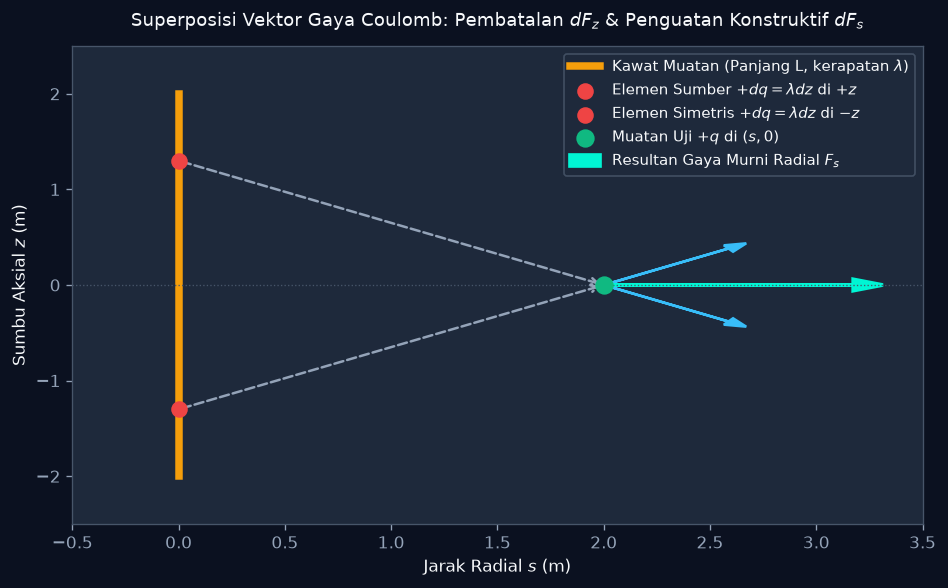

In [4]:
# Diagram Proyeksi Vektor 2D: Geometri Kawat Bermuatan & Penguraian Medan
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

L_val = 4.0
s_val = 2.0
zp_pos = 1.3

# Gambar kawat di sumbu z (vertikal)
ax.plot([0, 0], [-L_val/2, L_val/2], color='#f59e0b', linewidth=4.5, label=r'Kawat Muatan (Panjang L, kerapatan $\lambda$)')
ax.scatter([0], [zp_pos], color='#ef4444', s=80, zorder=5, label=r'Elemen Sumber $+dq = \lambda dz$ di $+z$')
ax.scatter([0], [-zp_pos], color='#ef4444', s=80, zorder=5, label=r'Elemen Simetris $+dq = \lambda dz$ di $-z$')

# Titik observasi muatan uji q
ax.scatter([s_val], [0], color='#10b981', s=100, zorder=5, label=r'Muatan Uji $+q$ di $(s, 0)$')

# Vektor perpindahan
ax.annotate('', xy=(s_val, 0), xytext=(0, zp_pos),
            arrowprops=dict(arrowstyle="->", color='#94a3b8', lw=1.5, ls='--'))
ax.annotate('', xy=(s_val, 0), xytext=(0, -zp_pos),
            arrowprops=dict(arrowstyle="->", color='#94a3b8', lw=1.5, ls='--'))

# Penguraian vektor gaya dF
scale = 0.7
theta = np.arctan2(zp_pos, s_val)
dF = scale
# Dari +z'
ax.arrow(s_val, 0, dF*np.cos(theta), -dF*np.sin(theta), head_width=0.08, head_length=0.1, fc='#38bdf8', ec='#38bdf8', lw=1.5)
# Dari -z'
ax.arrow(s_val, 0, dF*np.cos(theta), dF*np.sin(theta), head_width=0.08, head_length=0.1, fc='#38bdf8', ec='#38bdf8', lw=1.5)
# Resultan total murni radial
ax.arrow(s_val, 0, 2*dF*np.cos(theta), 0, head_width=0.12, head_length=0.14, fc='#00f5d4', ec='#00f5d4', lw=2.2, label=r'Resultan Gaya Murni Radial $F_s$')

ax.set_title('Superposisi Vektor Gaya Coulomb: Pembatalan $dF_z$ & Penguatan Konstruktif $dF_s$', fontsize=11, color='#f8fafc', pad=12)
ax.set_xlabel('Jarak Radial $s$ (m)', fontsize=10)
ax.set_ylabel('Sumbu Aksial $z$ (m)', fontsize=10)
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-2.5, 2.5)
ax.axhline(0, color='#475569', lw=0.8, ls=':')
ax.legend(loc='upper right', framealpha=0.85, facecolor='#1e293b', edgecolor='#475569', fontsize=9)
plt.tight_layout()
plt.show()


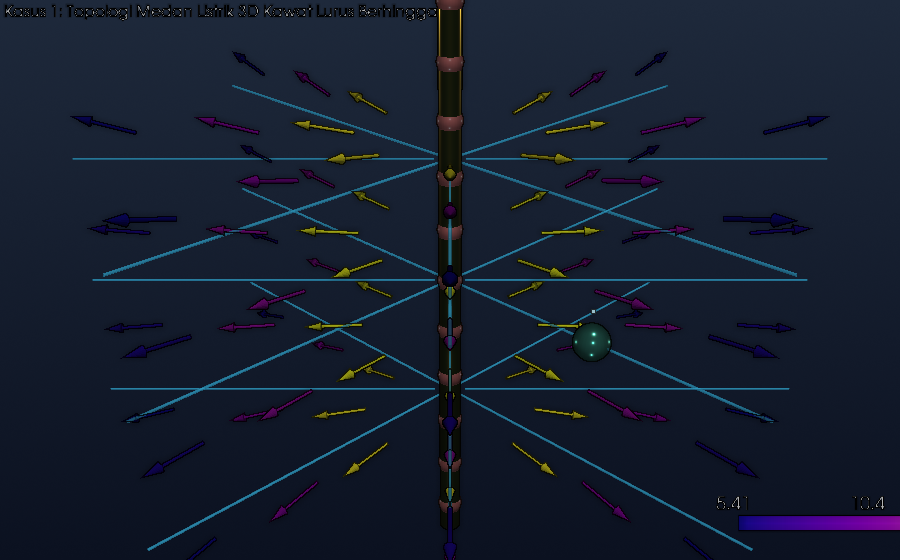

In [5]:
# Visualisasi 3D PyVista: Kawat Bermuatan Silindris & Medan Listrik Radial 3D
p1 = init_pyvista_plotter("Kasus 1: Topologi Medan Listrik 3D Kawat Lurus Berhingga")

L_wire = 2.4
R_wire = 0.045
wire = pv.Cylinder(center=(0, 0, 0), direction=(0, 0, 1), radius=R_wire, height=L_wire, resolution=60)
p1.add_mesh(wire, color='#f59e0b', pbr=True, metallic=0.9, roughness=0.18)

# Titik-titik muatan diskret di sepanjang kawat
z_pts = np.linspace(-L_wire/2 + 0.12, L_wire/2 - 0.12, 11)
for z in z_pts:
    sp_charge = pv.Sphere(radius=0.052, center=(0, 0, z))
    p1.add_mesh(sp_charge, color='#ef4444', pbr=True, roughness=0.25)

# Muatan uji di sekitar kawat
q_test = pv.Sphere(radius=0.07, center=(0.7, 0, 0))
p1.add_mesh(q_test, color='#10b981', pbr=True, metallic=0.5, roughness=0.2)
p1.add_point_labels([np.array([0.7, 0, 0.12])], ["Muatan Uji +q₀"], font_size=10, text_color='#10b981')

# Vektor medan listrik terdistribusi pada beberapa cincin radial
radii = [0.35, 0.70, 1.15]
thetas = np.linspace(0, 2*np.pi, 8, endpoint=False)
z_evals = [-0.6, -0.2, 0.2, 0.6]

starts, dirs, mags = [], [], []
for z_o in z_evals:
    for r_o in radii:
        for th in thetas:
            x = r_o * np.cos(th)
            y = r_o * np.sin(th)
            denom = np.sqrt(r_o**2 + (z_o - z_pts)**2)**3
            dEs = np.sum(r_o / denom)
            dEz = np.sum((z_o - z_pts) / denom)
            mag = np.sqrt(dEs**2 + dEz**2)
            starts.append([x, y, z_o])
            dirs.append([np.cos(th)*dEs/mag, np.sin(th)*dEs/mag, dEz/mag])
            mags.append(mag)

poly = pv.PolyData(np.array(starts))
poly['vectors'] = np.array(dirs)
poly['|E|'] = np.array(mags)

arrows = poly.glyph(orient='vectors', scale=False, factor=0.24,
                    geom=pv.Arrow(shaft_radius=0.035, tip_radius=0.09, tip_length=0.32))
p1.add_mesh(arrows, cmap='plasma', scalars='|E|', show_scalar_bar=True,
            scalar_bar_args={'title': '|E| (N/C)', 'color': '#f8fafc', 'position_x': 0.82})

# Tabung garis gaya radial (streamlines)
for th in np.linspace(0, 2*np.pi, 8, endpoint=False):
    for z_s in [-0.5, 0.0, 0.5]:
        r_line = np.linspace(0.06, 1.4, 25)
        pts_line = np.column_stack([r_line*np.cos(th), r_line*np.sin(th), np.full_like(r_line, z_s)])
        tube = pv.Spline(pts_line, 40).tube(radius=0.005)
        p1.add_mesh(tube, color='#38bdf8', opacity=0.55)

p1.camera_position = [(2.6, -2.6, 1.8), (0, 0, 0), (0, 0, 1)]
p1.show()
p1.close()


---
## 3. Kasus Analitik 2: Medan Listrik dan Hukum Gauss (Fluks Listrik & Simetri Tinggi)

### 3.1 Penurunan Matematis Eksak
Hukum Gauss menghubungkan fluks medan listrik total yang menembus permukaan tertutup $\mathcal{S} = \partial \mathcal{V}$ dengan muatan total $Q_{\text{enc}}$ yang dilingkupi:
$$\Phi_E = \oint_{\mathcal{S}} \mathbf{E} \cdot d\mathbf{a} = \frac{Q_{\text{enc}}}{\epsilon_0}$$

Berdasarkan Teorema Divergensi Gauss, hubungan integral ini ditransformasikan ke bentuk diferensial:
$$\oint_{\mathcal{S}} \mathbf{E} \cdot d\mathbf{a} = \int_{\mathcal{V}} (\nabla \cdot \mathbf{E}) d\tau = \frac{1}{\epsilon_0} \int_{\mathcal{V}} \rho d\tau \implies \nabla \cdot \mathbf{E} = \frac{\rho}{\epsilon_0}$$

#### Kasus Analitik: Bola Pejal Bermuatan Seragam
Tinjau sebuah bola isolator pejal beradius $R$ dengan muatan total $Q$ yang terdistribusi secara homogen dengan kerapatan muatan volume konstan $\rho_0 = \frac{Q}{\frac{4}{3}\pi R^3}$.

Pilih permukaan Gauss sferis konsentris beradius $r$. Karena simetri bola sempurna, medan listrik bersifat murni radial $\mathbf{E} = E(r) \hat{\mathbf{r}}$ dan magnitudonya konstan pada seluruh permukaan bola Gauss:
$$\oint_{\mathcal{S}} \mathbf{E} \cdot d\mathbf{a} = E(r) (4\pi r^2)$$

1. **Di Dalam Bola Pejal ($r \le R$):**
   $$Q_{\text{enc}} = \rho_0 \left(\frac{4}{3}\pi r^3\right) = Q \frac{r^3}{R^3}$$
   $$E_{\text{in}}(r) (4\pi r^2) = \frac{Q r^3}{\epsilon_0 R^3} \implies E_{\text{in}}(r) = \frac{Q r}{4\pi\epsilon_0 R^3} = \frac{\rho_0 r}{3\epsilon_0}$$
   Medan listrik di dalam bola tumbuh secara linear terhadap jarak radial $r$.

2. **Di Luar Bola Pejal ($r \ge R$):**
   $$Q_{\text{enc}} = Q$$
   $$E_{\text{out}}(r) (4\pi r^2) = \frac{Q}{\epsilon_0} \implies E_{\text{out}}(r) = \frac{Q}{4\pi\epsilon_0 r^2} = \frac{\rho_0 R^3}{3\epsilon_0 r^2}$$
   Medan listrik di luar bola meluruh sesuai hukum kuadrat terbalik (*inverse-square law*), identik dengan medan muatan titik yang terpusat di origin.

### 3.2 Penjelasan Fisis & Teorema Divergensi
Divergensi medan listrik di dalam bola adalah konstan: $\nabla \cdot \mathbf{E} = \frac{1}{r^2} \frac{\partial}{\partial r}(r^2 E_r) = \frac{\rho_0}{\epsilon_0}$. Di luar bola, kerapatan muatan lokal bernilai nol sehingga $\nabla \cdot \mathbf{E} = 0$. Pada batas $r = R$, medan listrik bersifat kontinu sempurna ($E_{\text{in}}(R) = E_{\text{out}}(R)$), namun turunan pertamanya mengalami diskontinuitas akibat lompatan kerapatan muatan $\Delta \rho = -\rho_0$.

### 3.3 Formulasi Persamaan Superposisi pada Medan Listrik & Hukum Gauss
1. **Superposisi Fluks Medan Listrik:**
   Linearitas operator integral memastikan bahwa jika suatu sistem tersusun atas beberapa sumber muatan berbeda, fluks listrik total merupakan penjumlahan aljabar dari fluks masing-masing sumber:
   $$\Phi_E = \oint_{\mathcal{S}} \left( \sum_{i=1}^N \mathbf{E}_i \right) \cdot d\mathbf{a} = \sum_{i=1}^N \oint_{\mathcal{S}} \mathbf{E}_i \cdot d\mathbf{a} = \frac{\sum_{i=1}^N Q_{\text{enc},i}}{\epsilon_0}$$

2. **Superposisi Kulit Sferis Konsentris (Teorema Kulit Newton):**
   Bola pejal dapat dipandang sebagai superposisi kontinu dari kulit-kulit sferis infinitesimal berjejari $r'$ dengan muatan $dq' = \rho_0 (4\pi r'^2 dr')$. Berdasarkan teorema kulit:
   - Kulit-kulit luar ($r' > r$) menghasilkan superposisi medan nol di titik $r$.
   - Kulit-kulit dalam ($r' \le r$) menghasilkan superposisi medan ekivalen dengan seluruh muatan bagian dalam terpusat di titik asal.
   Melalui integral superposisi kulit:
   $$\mathbf{E}(r) = \int_0^R d\mathbf{E}_{\text{kulit}} = \int_0^r \frac{\rho_0 (4\pi r'^2 dr')}{4\pi\epsilon_0 r^2} \hat{\mathbf{r}} + \int_r^R \mathbf{0} = \frac{\rho_0 r}{3\epsilon_0} \hat{\mathbf{r}}$$

3. **Aplikasi Superposisi pada Problem Rongga (*Spherical Cavity Problem*):**
   Tinjau sebuah bola pejal seragam beradius $R$ bermuatan $+\rho_0$ yang memiliki rongga sferis beradius $a$ yang digeser sejauh vektor $\mathbf{d}$ dari pusat bola. Melalui prinsip superposisi linear:
   $$\mathbf{E}_{\text{rongga}}(\mathbf{r}) = \mathbf{E}_{\text{bola penuh}}(\mathbf{r}, +\rho_0) + \mathbf{E}_{\text{bola rongga}}(\mathbf{r} - \mathbf{d}, -\rho_0)$$
   $$\mathbf{E}_{\text{rongga}}(\mathbf{r}) = \frac{\rho_0}{3\epsilon_0} \mathbf{r} + \frac{-\rho_0}{3\epsilon_0} (\mathbf{r} - \mathbf{d}) = \frac{\rho_0}{3\epsilon_0} \mathbf{d}$$
   Persamaan superposisi membuktikan secara elegan bahwa medan listrik di dalam sembarang rongga bola eksentrik bersifat **konstan dan homogen seragam** sempurna searah pergeseran $\mathbf{d}$!


In [6]:
# Verifikasi Simbolik SymPy: Hukum Gauss & Divergensi Medan Bola Pejal
r_sym, R_sym, Q_sym, rho0_sym, eps0_sym = sp.symbols('r R Q rho_0 epsilon_0', positive=True, real=True)

# Definisi medan listrik dalam dan luar
E_in_sym = (rho0_sym * r_sym) / (3 * eps0_sym)
E_out_sym = (rho0_sym * R_sym**3) / (3 * eps0_sym * r_sym**2)

# Divergensi koordinat bola: div(E) = (1/r^2) * d/dr (r^2 * E_r)
div_E_in = sp.simplify((1 / r_sym**2) * sp.diff(r_sym**2 * E_in_sym, r_sym))
div_E_out = sp.simplify((1 / r_sym**2) * sp.diff(r_sym**2 * E_out_sym, r_sym))

# Diskontinuitas turunan dE/dr di batas r = R
dE_in_dr = sp.diff(E_in_sym, r_sym).subs(r_sym, R_sym)
dE_out_dr = sp.diff(E_out_sym, r_sym).subs(r_sym, R_sym)
delta_dE_dr = sp.simplify(dE_out_dr - dE_in_dr)

print("=== VERIFIKASI SIMBOLIK SYMPY: HUKUM GAUSS & TEOREMA DIVERGENSI ===")
print(f"Divergensi di dalam bola (r < R) : div(E) = {div_E_in} (Sesuai Persamaan Maxwell: rho_0 / epsilon_0)")
print(f"Divergensi di luar bola (r > R)  : div(E) = {div_E_out} (Sesuai Ruang Hampa: 0)")
print(f"Kontinuitas E(R)                 : E_in(R) - E_out(R) = {sp.simplify(E_in_sym.subs(r_sym, R_sym) - E_out_sym.subs(r_sym, R_sym))}")
print(f"Lompatan Turunan [dE/dr] di r=R  : Delta(dE/dr) = {delta_dE_dr}")
print(f"Kesetaraan Fisis Lompatan        : -rho_0 / epsilon_0 = {-rho0_sym/eps0_sym}")
assert sp.simplify(delta_dE_dr - (-rho0_sym/eps0_sym)) == 0, "Lompatan fluks diferensial tidak konsisten!"
print("Verifikasi Diferensial Teorema Gauss: SUKSES SEMPURNA")


=== VERIFIKASI SIMBOLIK SYMPY: HUKUM GAUSS & TEOREMA DIVERGENSI ===
Divergensi di dalam bola (r < R) : div(E) = rho_0/epsilon_0 (Sesuai Persamaan Maxwell: rho_0 / epsilon_0)
Divergensi di luar bola (r > R)  : div(E) = 0 (Sesuai Ruang Hampa: 0)
Kontinuitas E(R)                 : E_in(R) - E_out(R) = 0
Lompatan Turunan [dE/dr] di r=R  : Delta(dE/dr) = -rho_0/epsilon_0
Kesetaraan Fisis Lompatan        : -rho_0 / epsilon_0 = -rho_0/epsilon_0
Verifikasi Diferensial Teorema Gauss: SUKSES SEMPURNA


<string>:6: RuntimeWarning: divide by zero encountered in divide
<string>:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


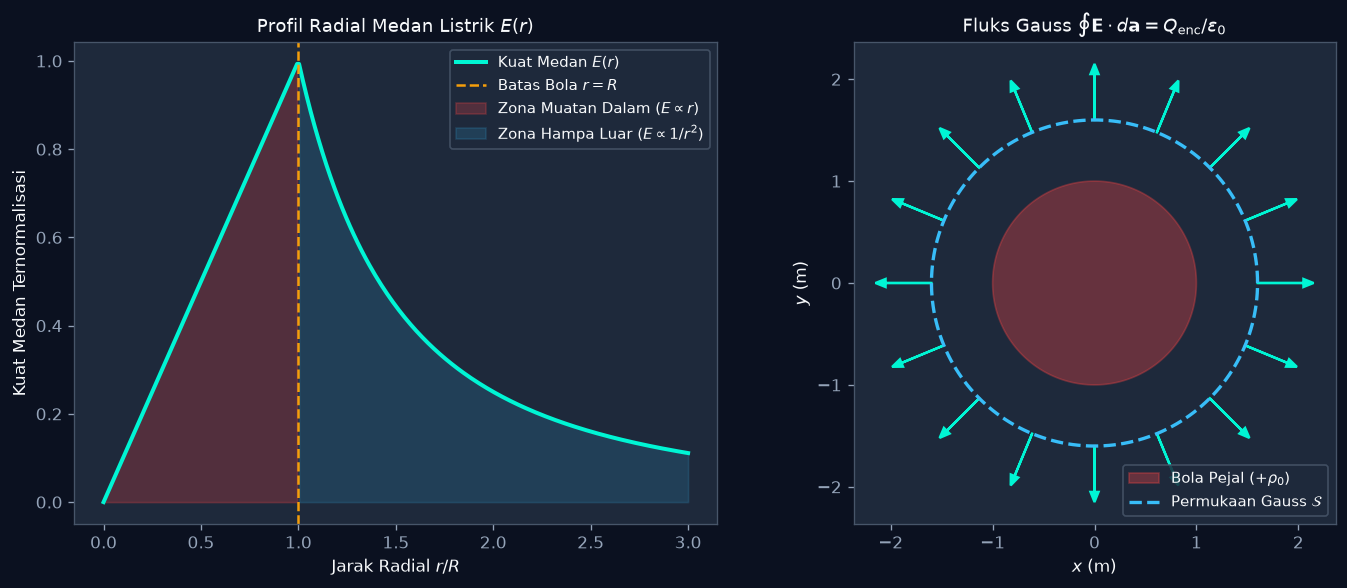

In [7]:
# Diagram Proyeksi Vektor 2D: Profil Medan Radial E(r) & Permukaan Gauss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

R_val = 1.0
r_arr = np.linspace(0, 3.0, 300)
E_arr = np.where(r_arr <= R_val, r_arr / R_val**3, 1.0 / r_arr**2)

# Subplot 1: Kurva E(r)
ax1.plot(r_arr, E_arr, color='#00f5d4', lw=2.4, label='Kuat Medan $E(r)$')
ax1.axvline(R_val, color='#f59e0b', ls='--', lw=1.5, label='Batas Bola $r = R$')
ax1.fill_between(r_arr[r_arr <= R_val], 0, E_arr[r_arr <= R_val], color='#ef4444', alpha=0.25, label='Zona Muatan Dalam ($E \\propto r$)')
ax1.fill_between(r_arr[r_arr >= R_val], 0, E_arr[r_arr >= R_val], color='#38bdf8', alpha=0.15, label='Zona Hampa Luar ($E \\propto 1/r^2$)')
ax1.set_title('Profil Radial Medan Listrik $E(r)$', fontsize=11, color='#f8fafc')
ax1.set_xlabel('Jarak Radial $r/R$', fontsize=10)
ax1.set_ylabel('Kuat Medan Ternormalisasi', fontsize=10)
ax1.legend(loc='upper right', framealpha=0.85, facecolor='#1e293b', edgecolor='#475569', fontsize=9)

# Subplot 2: Penampang 2D Bola & Fluks Menembus Permukaan Gauss
theta_circ = np.linspace(0, 2*np.pi, 200)
ax2.fill(R_val*np.cos(theta_circ), R_val*np.sin(theta_circ), color='#ef4444', alpha=0.35, label='Bola Pejal ($+\\rho_0$)')
r_gauss = 1.6
ax2.plot(r_gauss*np.cos(theta_circ), r_gauss*np.sin(theta_circ), color='#38bdf8', ls='--', lw=2.0, label='Permukaan Gauss $\\mathcal{S}$')

# Vektor medan menembus normal
for th in np.linspace(0, 2*np.pi, 16, endpoint=False):
    ax2.arrow(r_gauss*np.cos(th), r_gauss*np.sin(th), 0.45*np.cos(th), 0.45*np.sin(th),
              head_width=0.08, head_length=0.1, fc='#00f5d4', ec='#00f5d4', lw=1.4)

ax2.set_aspect('equal')
ax2.set_title('Fluks Gauss $\\oint \\mathbf{E} \\cdot d\\mathbf{a} = Q_{\\text{enc}}/\\epsilon_0$', fontsize=11, color='#f8fafc')
ax2.set_xlabel('$x$ (m)', fontsize=10)
ax2.set_ylabel('$y$ (m)', fontsize=10)
ax2.legend(loc='lower right', framealpha=0.85, facecolor='#1e293b', edgecolor='#475569', fontsize=9)

plt.tight_layout()
plt.show()


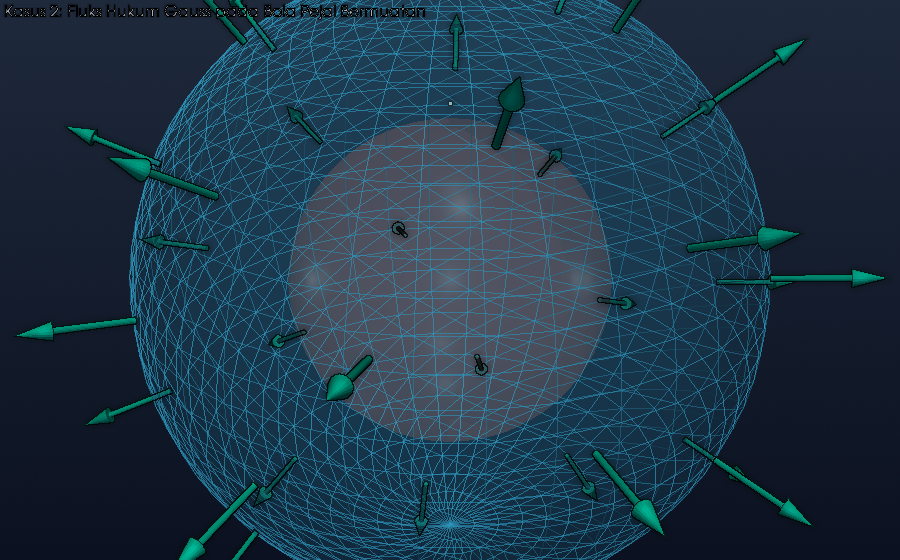

In [8]:
# Visualisasi 3D PyVista: Bola Pejal Bermuatan & Permukaan Gauss Konsentris
p2 = init_pyvista_plotter("Kasus 2: Fluks Hukum Gauss pada Bola Pejal Bermuatan")

R_sphere = 0.6
charge_sphere = pv.Sphere(radius=R_sphere, center=(0, 0, 0), theta_resolution=60, phi_resolution=60)
p2.add_mesh(charge_sphere, color='#ef4444', opacity=0.45, pbr=True, roughness=0.3)
p2.add_point_labels([np.array([0, 0, R_sphere + 0.08])], ["Bola Pejal Bermuatan (+ρ₀)"], font_size=10, text_color='#ef4444')

# Permukaan Gauss konsentris r_G = 1.15
r_gauss = 1.15
gauss_sphere = pv.Sphere(radius=r_gauss, center=(0, 0, 0), theta_resolution=36, phi_resolution=36)
p2.add_mesh(gauss_sphere, color='#38bdf8', opacity=0.15, style='surface')
p2.add_mesh(gauss_sphere, color='#38bdf8', opacity=0.4, style='wireframe', line_width=1.0)
p2.add_point_labels([np.array([0, 0, r_gauss + 0.1])], ["Permukaan Gauss Konsentris S"], font_size=10, text_color='#38bdf8')

# Titik-titik distribusi bola seragam (Fibonacci Sphere Distribution)
n_pts = 36
indices = np.arange(0, n_pts, dtype=float) + 0.5
phi = np.arccos(1 - 2*indices/n_pts)
theta = np.pi * (1 + 5**0.5) * indices
x = r_gauss * np.sin(phi) * np.cos(theta)
y = r_gauss * np.sin(phi) * np.sin(theta)
z = r_gauss * np.cos(phi)
pts = np.column_stack([x, y, z])
normals = pts / r_gauss

poly = pv.PolyData(pts)
poly['vectors'] = normals
arrows = poly.glyph(orient='vectors', scale=False, factor=0.38,
                    geom=pv.Arrow(shaft_radius=0.035, tip_radius=0.09, tip_length=0.32))
p2.add_mesh(arrows, color='#00f5d4')

p2.camera_position = [(2.5, -2.5, 1.7), (0, 0, 0), (0, 0, 1)]
p2.show()
p2.close()


---
## 4. Kasus Analitik 3: Potensial Listrik dan Energi Potensial (Persamaan Laplace & Poisson)

### 4.1 Penurunan Matematis Eksak
Karena curl medan elektrostatik identik nol ($\nabla \times \mathbf{E} = \mathbf{0}$), integral garis $\int_{\mathbf{a}}^{\mathbf{b}} \mathbf{E} \cdot d\mathbf{l}$ bersifat independen terhadap lintasan. Kita dapat mendefinisikan **potensial skalar** $V(\mathbf{r})$ dengan titik acuan nol di tak hingga:
$$V(\mathbf{r}) = -\int_{\infty}^{\mathbf{r}} \mathbf{E} \cdot d\mathbf{l} \iff \mathbf{E} = -\nabla V$$

#### Potensial Skalar Bola Pejal Bermuatan Seragam
1. **Di Luar Bola ($r \ge R$):**
   $$V_{\text{out}}(r) = -\int_{\infty}^r \frac{Q}{4\pi\epsilon_0 r'^2} dr' = \frac{Q}{4\pi\epsilon_0 r}$$
2. **Di Dalam Bola ($r \le R$):**
   $$V_{\text{in}}(r) = V_{\text{out}}(R) - \int_R^r \frac{Q r'}{4\pi\epsilon_0 R^3} dr' = \frac{Q}{8\pi\epsilon_0 R} \left( 3 - \frac{r^2}{R^2} \right)$$

Pada pusat bola ($r = 0$), potensial mencapai nilai puncak $V(0) = \frac{3}{2} V(R)$.

#### Energi Elektrostatik Total yang Tersimpan
Energi yang dibutuhkan untuk merakit distribusi muatan elektrostatik kontinu dihitung melalui:
$$W = \frac{1}{2} \int_{\mathcal{V}} \rho V d\tau = \frac{\epsilon_0}{2} \int_{\text{seluruh ruang}} E^2 d\tau = \frac{3}{5} \frac{Q^2}{4\pi\epsilon_0 R}$$

### 4.2 Penjelasan Fisis & Hubungan dengan Persamaan Laplace
Di luar bola, $\rho = 0$, sehingga potensial memenuhi **Persamaan Laplace**: $\nabla^2 V = 0$. Solusi persamaan Laplace memiliki sifat nilai rata-rata (*mean value theorem*) dan tidak memiliki nilai ekstrem lokal di ruang hampa (**Teorema Earnshaw**).

### 4.3 Formulasi Persamaan Superposisi: Skalar Potensial vs Non-Linearitas Energi
1. **Keunggulan Superposisi Skalar Potensial Listrik:**
   Karena potensial $V$ adalah besaran skalar, prinsip superposisi potensial skalar tidak memerlukan proyeksi vektor trigonometri:
   $$V(\mathbf{r}) = \sum_{i=1}^N V_i(\mathbf{r}) = \frac{1}{4\pi\epsilon_0} \sum_{i=1}^N \frac{q_i}{|\mathbf{r} - \mathbf{r}_i|}, \quad V(\mathbf{r}) = \frac{1}{4\pi\epsilon_0} \int \frac{\rho(\mathbf{r}')}{|\mathbf{r} - \mathbf{r}'|} d\tau'$$
   Linearitas operator diferensial gradien menjamin bahwa medan listrik hasil gradien potensial gabungan identik dengan superposisi medan vektor:
   $$\mathbf{E}(\mathbf{r}) = -\nabla V(\mathbf{r}) = -\nabla \left( \sum_i V_i \right) = \sum_i (-\nabla V_i) = \sum_i \mathbf{E}_i(\mathbf{r})$$

2. **Non-Linearitas Superposisi Energi Elektrostatik:**
   *Catatan Fundamental:* Prinsip superposisi **TIDAK berlaku secara linear untuk energi elektrostatik total**. Karena kerapatan energi elektrostatik sebanding dengan kuadrat medan ($u = \frac{1}{2}\epsilon_0 E^2$):
   $$W_{\text{total}} = \frac{\epsilon_0}{2} \int |\mathbf{E}_1 + \mathbf{E}_2|^2 d\tau = \frac{\epsilon_0}{2} \int \left( E_1^2 + E_2^2 + 2 \mathbf{E}_1 \cdot \mathbf{E}_2 \right) d\tau$$
   $$W_{\text{total}} = W_1 + W_2 + W_{12}$$
   di mana suku silang (*cross term*) $W_{12}$ merepresentasikan **energi interaksi elektrostatik mutual**:
   $$W_{12} = \epsilon_0 \int \mathbf{E}_1 \cdot \mathbf{E}_2 d\tau = \int \rho_1 V_2 d\tau = \int \rho_2 V_1 d\tau$$
   Energi total sistem mencakup energi mandiri (*self-energy*) dari masing-masing muatan ditambah kerja eksternal untuk menyatukan muatan melawan gaya tolak/tarik antar-muatan.


In [9]:
# Verifikasi Simbolik SymPy: Potensial Listrik & Kesetaraan Energi Medan
r_s, R_s, Q_s, eps0_s = sp.symbols('r R Q epsilon_0', positive=True, real=True)

# 1. Integrasi Potensial
V_out_sym = -sp.integrate(Q_s / (4 * sp.pi * eps0_s * r_s**2), (r_s, sp.oo, r_s))
V_in_sym = V_out_sym.subs(r_s, R_s) - sp.integrate((Q_s * r_s) / (4 * sp.pi * eps0_s * R_s**3), (r_s, R_s, r_s))

# 2. Verifikasi E = -grad(V)
E_out_check = -sp.diff(V_out_sym, r_s)
E_in_check = -sp.diff(V_in_sym, r_s)

# 3. Energi Elektrostatik: Integral 1/2 * rho * V
rho_val = Q_s / (sp.Rational(4, 3) * sp.pi * R_s**3)
W_rho_V = sp.Rational(1, 2) * sp.integrate(rho_val * V_in_sym * 4 * sp.pi * r_s**2, (r_s, 0, R_s))

# 4. Energi Elektrostatik: Integral 1/2 * epsilon_0 * E^2
W_E2_in = (eps0_s / 2) * sp.integrate(E_in_check**2 * 4 * sp.pi * r_s**2, (r_s, 0, R_s))
W_E2_out = (eps0_s / 2) * sp.integrate(E_out_check**2 * 4 * sp.pi * r_s**2, (r_s, R_s, sp.oo))
W_E2_total = sp.simplify(W_E2_in + W_E2_out)

print("=== VERIFIKASI SIMBOLIK SYMPY: POTENSIAL & ENERGI ELEKTROSTATIK ===")
print(f"Potensial Luar V_out(r) = {V_out_sym}")
print(f"Potensial Dalam V_in(r) = {sp.factor(V_in_sym)}")
print(f"Verifikasi E_out        = {E_out_check} (Sesuai Coulomb)")
print(f"Verifikasi E_in         = {E_in_check} (Sesuai Gauss)")
print(f"Energi W via (1/2 int rho*V) : {W_rho_V}")
print(f"Energi W via (eps0/2 int E^2): {W_E2_total}")
assert sp.simplify(W_rho_V - W_E2_total) == 0, "Ketidakkonsistenan energi elektrostatik!"
print("Teorema Kesetaraan Energi Medan: TERBUKTI IDENTIK EKSAT (3/5 * Q^2 / (4*pi*eps0*R))")


=== VERIFIKASI SIMBOLIK SYMPY: POTENSIAL & ENERGI ELEKTROSTATIK ===
Potensial Luar V_out(r) = Q/(4*pi*epsilon_0*r)
Potensial Dalam V_in(r) = -Q*(-3*R**2 + r**2)/(8*pi*R**3*epsilon_0)
Verifikasi E_out        = Q/(4*pi*epsilon_0*r**2) (Sesuai Coulomb)
Verifikasi E_in         = Q*r/(4*pi*R**3*epsilon_0) (Sesuai Gauss)
Energi W via (1/2 int rho*V) : 3*Q**2/(20*pi*R*epsilon_0)
Energi W via (eps0/2 int E^2): 3*Q**2/(20*pi*R*epsilon_0)
Teorema Kesetaraan Energi Medan: TERBUKTI IDENTIK EKSAT (3/5 * Q^2 / (4*pi*eps0*R))


<string>:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


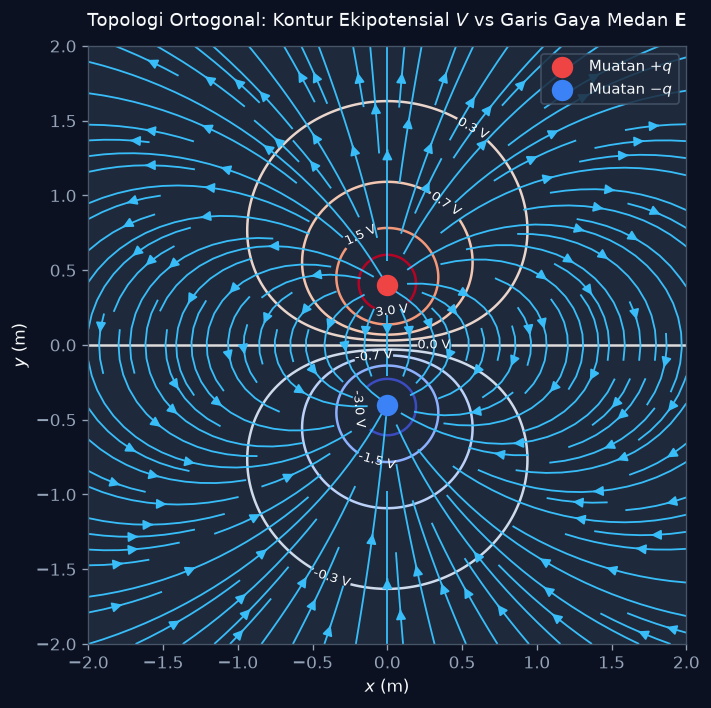

In [10]:
# Diagram Proyeksi Vektor 2D: Kontur Ekipotensial & Garis Gaya Medan Dipol
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

d_sep = 0.8
y_grid, x_grid = np.mgrid[-2:2:200j, -2:2:200j]

# Dipol listrik di (0, d/2) dan (0, -d/2)
r_pos = np.sqrt(x_grid**2 + (y_grid - d_sep/2)**2) + 0.05
r_neg = np.sqrt(x_grid**2 + (y_grid + d_sep/2)**2) + 0.05
V_dipole = 1.0 / r_pos - 1.0 / r_neg

# Kontur Ekipotensial
levels = [-3, -1.5, -0.7, -0.3, 0.0, 0.3, 0.7, 1.5, 3]
cs = ax.contour(x_grid, y_grid, V_dipole, levels=levels, cmap='coolwarm', linewidths=1.5)
ax.clabel(cs, inline=True, fontsize=8, fmt='%1.1f V', colors='#f8fafc')

# Garis Gaya Medan Listrik E = -grad(V)
Ey, Ex = np.gradient(-V_dipole, 4.0/200, 4.0/200)
ax.streamplot(x_grid, y_grid, Ex, Ey, color='#38bdf8', linewidth=1.1, density=1.3, arrowsize=1.2)

# Muatan Dipol
ax.scatter([0], [d_sep/2], color='#ef4444', s=140, zorder=6, label='Muatan $+q$')
ax.scatter([0], [-d_sep/2], color='#3b82f6', s=140, zorder=6, label='Muatan $-q$')

ax.set_title('Topologi Ortogonal: Kontur Ekipotensial $V$ vs Garis Gaya Medan $\\mathbf{E}$',
             fontsize=11, color='#f8fafc', pad=12)
ax.set_xlabel('$x$ (m)', fontsize=10)
ax.set_ylabel('$y$ (m)', fontsize=10)
ax.set_aspect('equal')
ax.legend(loc='upper right', framealpha=0.85, facecolor='#1e293b', edgecolor='#475569', fontsize=9)
plt.tight_layout()
plt.show()


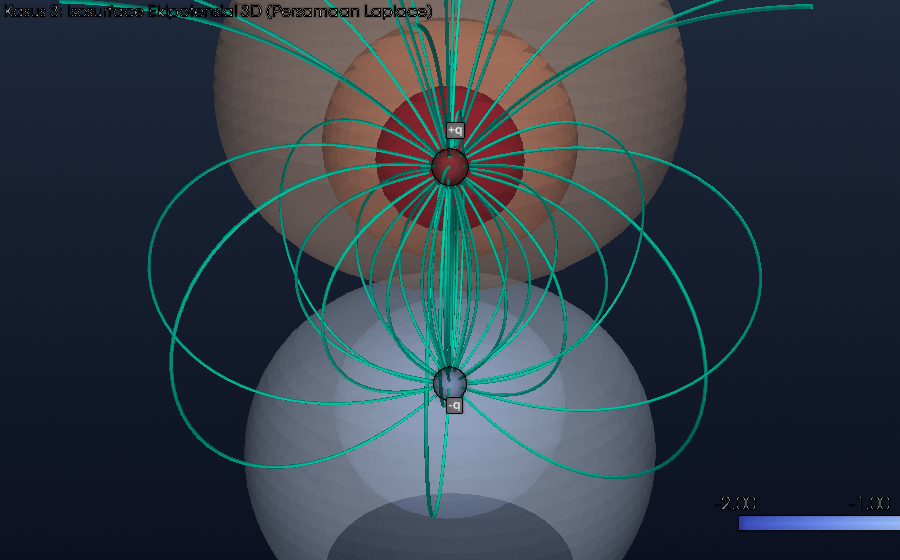

In [11]:
# Visualisasi 3D PyVista: Isosurface Ekipotensial Bertingkat Dipol Listrik
p3 = init_pyvista_plotter("Kasus 3: Isosurface Ekipotensial 3D (Persamaan Laplace)")

grid = pv.ImageData(dimensions=(45, 45, 45), spacing=(0.06, 0.06, 0.06), origin=(-1.32, -1.32, -1.32))
x, y, z = grid.points.T
d = 0.45
r1 = np.sqrt(x**2 + y**2 + (z - d)**2) + 0.06
r2 = np.sqrt(x**2 + y**2 + (z + d)**2) + 0.06
V = 1.0 / r1 - 1.0 / r2
grid['potential'] = V

# Ekstraksi Isosurface Ekipotensial
iso_vals = [-2.0, -1.0, -0.4, 0.4, 1.0, 2.0]
isos = grid.contour(isosurfaces=iso_vals, scalars='potential')
p3.add_mesh(isos, cmap='coolwarm', opacity=0.45, show_scalar_bar=True,
            scalar_bar_args={'title': 'Potensial V (Volt)', 'color': '#f8fafc', 'position_x': 0.82})

# Bola muatan dipol
p3.add_mesh(pv.Sphere(radius=0.07, center=(0, 0, d)), color='#ef4444', pbr=True, roughness=0.25)
p3.add_mesh(pv.Sphere(radius=0.07, center=(0, 0, -d)), color='#3b82f6', pbr=True, roughness=0.25)
p3.add_point_labels([np.array([0, 0, d + 0.12]), np.array([0, 0, -d - 0.12])],
                   ["+q", "-q"], font_size=11, text_color='#f8fafc')

# Garis medan 3D melengkung dari +q ke -q
thetas_emit = np.linspace(0.1*np.pi, 0.9*np.pi, 6)
phis = np.linspace(0, 2*np.pi, 8, endpoint=False)
for th in thetas_emit:
    for ph in phis:
        pos = np.array([0.08*np.sin(th)*np.cos(ph), 0.08*np.sin(th)*np.sin(ph), d + 0.08*np.cos(th)])
        pts = [pos.copy()]
        for _ in range(80):
            r_pos = pos - np.array([0, 0, d])
            r_neg = pos - np.array([0, 0, -d])
            d1 = np.linalg.norm(r_pos) + 1e-4
            d2 = np.linalg.norm(r_neg) + 1e-4
            E = r_pos/(d1**3) - r_neg/(d2**3)
            magE = np.linalg.norm(E)
            pos = pos + 0.035 * (E / magE)
            pts.append(pos.copy())
            if np.linalg.norm(pos - np.array([0, 0, -d])) < 0.08 or np.linalg.norm(pos) > 1.8:
                break
        if len(pts) > 3:
            tube = pv.Spline(np.array(pts), 50).tube(radius=0.006)
            p3.add_mesh(tube, color='#00f5d4', opacity=0.7)

p3.camera_position = [(2.8, -2.5, 1.5), (0, 0, 0), (0, 0, 1)]
p3.show()
p3.close()


---
## 5. Kasus Analitik 4: Syarat Batas & Masalah Nilai Batas (Metode Keunikan dan Separasi Variabel)

### 5.1 Penurunan Matematis Eksak Syarat Batas Elektrostatik
Pada antarmuka antara dua medium yang memuat kerapatan muatan permukaan bebas $\sigma$, medan elektrostatik mengalami diskontinuitas sesuai syarat batas fundamental yang diturunkan dari persamaan Maxwell elektrostatik:
1. **Diskontinuitas Komponen Normal (dari Hukum Gauss):**
   Dengan membangun pilbox Gaussian silindris infinitesimal melintasi batas berorientasi normal $\hat{\mathbf{n}}$ dari medium 2 ke medium 1:
   $$\oint \mathbf{E} \cdot d\mathbf{a} = (E_1^\perp - E_2^\perp) A = \frac{\sigma A}{\epsilon_0} \implies E_1^\perp - E_2^\perp = \frac{\sigma}{\epsilon_0}$$
   Dalam representasi potensial skalar ($E^\perp = -\partial V/\partial n$):
   $$\left. \frac{\partial V_1}{\partial n} \right|_{\text{batas}} - \left. \frac{\partial V_2}{\partial n} \right|_{\text{batas}} = -\frac{\sigma}{\epsilon_0}$$
2. **Kontinuitas Komponen Tangensial (dari $\nabla \times \mathbf{E} = \mathbf{0}$):**
   Dengan membangun loop integrasi persegi panjang tipis menyusuri permukaan antarmuka:
   $$\oint \mathbf{E} \cdot d\mathbf{l} = (E_1^\parallel - E_2^\parallel) L = 0 \implies E_1^\parallel - E_2^\parallel = 0$$
   Yang setara dengan kontinuitas potensial skalar melintasi antarmuka:
   $$V_1(\mathbf{r}_{\text{batas}}) = V_2(\mathbf{r}_{\text{batas}})$$
3. **Syarat Batas pada Konduktor Ideal:**
   Di dalam konduktor statis, muatan bebas terdistribusi sedemikian hingga $\mathbf{E} = \mathbf{0}$ di seluruh volume konduktor (*equipotential volume*). Akibatnya, medan listrik tepat di luar permukaan konduktor harus selalu tegak lurus sempurna terhadap permukaan:
   $$\mathbf{E} = \frac{\sigma}{\epsilon_0} \hat{\mathbf{n}}, \quad E^\parallel = 0$$

### 5.2 Metode Keunikan (Uniqueness Theorems)
Ketika menyelesaikan Persamaan Laplace $\nabla^2 V = 0$ dalam suatu domain dengan syarat batas tertentu, bagaimana kita yakin bahwa solusi yang kita temukan adalah satu-satunya solusi yang benar? Pertanyaan mendasar ini dijawab secara pasti oleh **Teorema Keunikan**:

#### Teorema Keunikan Pertama (First Uniqueness Theorem - Syarat Batas Dirichlet)
> **Teorema:** Solusi persamaan Laplace $\nabla^2 V = 0$ dalam suatu volume tertutup $\mathcal{V}$ **ditentukan secara tunggal dan unik** jika nilai potensial $V$ pada seluruh permukaan batas $\mathcal{S} = \partial \mathcal{V}$ telah dispesifikasi.

**Pembuktian Matematis Eksak (Identitas Green):**
Andaikan terdapat dua solusi potensial berbeda, $V_1(\mathbf{r})$ dan $V_2(\mathbf{r})$, yang sama-sama memenuhi persamaan Laplace di dalam $\mathcal{V}$ dan memenuhi syarat batas Dirichlet yang identik pada seluruh permukaan $\mathcal{S}$:
$$\nabla^2 V_1 = 0, \quad \nabla^2 V_2 = 0 \quad (\text{di dalam } \mathcal{V})$$
$$V_1 = V_2 = V_b \quad (\text{pada permukaan batas } \mathcal{S})$$

Definisikan fungsi selisih potensial:
$$V_d(\mathbf{r}) \equiv V_1(\mathbf{r}) - V_2(\mathbf{r})$$
Karena persamaan Laplace bersifat linear, $V_d$ memenuhi:
$$\nabla^2 V_d = \nabla^2 V_1 - \nabla^2 V_2 = 0 \quad (\text{di dalam } \mathcal{V})$$
$$V_d(\mathbf{r}) = V_1 - V_2 = 0 \quad (\text{pada permukaan batas } \mathcal{S})$$

Tinjau divergensi dari medan vektor $V_d \nabla V_d$ dengan menggunakan aturan rantai diferensial:
$$\nabla \cdot (V_d \nabla V_d) = (\nabla V_d) \cdot (\nabla V_d) + V_d (\nabla^2 V_d) = (\nabla V_d)^2 + 0 = (\nabla V_d)^2$$

Integrasikan identitas ini ke seluruh volume $\mathcal{V}$ dan terapkan Teorema Divergensi Gauss:
$$\int_{\mathcal{V}} (\nabla V_d)^2 d\tau = \int_{\mathcal{V}} \nabla \cdot (V_d \nabla V_d) d\tau = \oint_{\mathcal{S}} V_d \nabla V_d \cdot d\mathbf{a}$$

Karena pada seluruh permukaan batas $\mathcal{S}$ nilai $V_d = 0$, maka integral permukaan di ruas kanan identik lenyap:
$$\int_{\mathcal{V}} (\nabla V_d)^2 d\tau = 0$$

Perhatikan bahwa integran $(\nabla V_d)^2 = |\nabla V_d|^2 \ge 0$ bernilai kuadratik riil (non-negatif di setiap titik di dalam $\mathcal{V}$). Satu-satunya cara integral volume dari fungsi non-negatif menghasilkan nilai tepat nol adalah jika integrannya nol di seluruh titik:
$$\nabla V_d = \mathbf{0} \quad \text{di setiap titik dalam } \mathcal{V}$$

Gradien yang lenyap mengimplikasikan bahwa $V_d(\mathbf{r}) = \text{konstan}$. Karena $V_d = 0$ pada permukaan batas $\mathcal{S}$, maka konstanta tersebut haruslah nol:
$$V_d(\mathbf{r}) = 0 \implies V_1(\mathbf{r}) = V_2(\mathbf{r}) \quad \forall \mathbf{r} \in \mathcal{V}$$
**Q.E.D.** Solusi persamaan Laplace terbukti tunggal dan unik!

#### Teorema Keunikan Kedua (Second Uniqueness Theorem - Syarat Batas Neumann)
Dalam suatu volume $\mathcal{V}$ yang memuat beberapa konduktor dengan muatan total $Q_1, Q_2, \dots, Q_m$ yang ditentukan, medan listrik $\mathbf{E} = -\nabla V$ di seluruh ruang ditentukan secara unik.

### 5.3 Metode Separasi Variabel pada Persamaan Laplace
Metode Separasi Variabel (*Separation of Variables*) merupakan teknik analitik paling berdaya guna untuk menyelesaikan persamaan diferensial parsial eliptik Laplace.

Tinjau Persamaan Laplace 2-Dimensi dalam koordinat Kartesian:
$$\nabla^2 V = \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = 0$$

Asumsikan solusi berbentuk perkalian dua fungsi variabel terpisah (*ansatz product*):
$$V(x, y) = X(x) Y(y)$$
Substitusi ke dalam persamaan Laplace dan bagi kedua ruas dengan $X(x)Y(y)$:
$$\frac{1}{X(x)} \frac{d^2 X}{dx^2} + \frac{1}{Y(y)} \frac{d^2 Y}{dy^2} = 0 \iff \frac{1}{X} \frac{d^2 X}{dx^2} = -\frac{1}{Y} \frac{d^2 Y}{dy^2}$$

Ruas kiri hanya bergantung pada $x$, sedangkan ruas kanan hanya bergantung pada $y$. Kedua ruas hanya bisa sama jika keduanya sama dengan konstanta pemisah (*separation constant*) $-k^2$:
$$\frac{d^2 X}{dx^2} + k^2 X = 0 \implies X(x) = A\cos(kx) + B\sin(kx)$$
$$\frac{d^2 Y}{dy^2} - k^2 Y = 0 \implies Y(y) = C\cosh(ky) + D\sinh(ky)$$

#### Studi Kasus Analitik: Saluran Konduktor Persegi Panjang Tak Hingga (Rectangular Waveguide Conduit)
Tinjau sebuah saluran pipa konduktor berpenampang persegi panjang dengan lebar $a$ (sumbu-$x$) dan tinggi $b$ (sumbu-$y$). Dinding samping ($x = 0$ dan $x = a$) serta dinding bawah ($y = 0$) berstatus grounding ($V = 0$). Pelat atas di $y = b$ diisolasi dan dijaga pada potensial konstan $V_0$:
1. $V(0, y) = 0 \implies A = 0 \implies X(x) = B\sin(kx)$
2. $V(a, y) = 0 \implies \sin(ka) = 0 \implies k_n = \frac{n\pi}{a} \quad (n = 1, 2, 3, \dots)$
3. $V(x, 0) = 0 \implies C = 0 \implies Y(y) = D\sinh\left(\frac{n\pi y}{a}\right)$

Solusi moda individual untuk setiap bilangan bulat $n$ adalah:
$$V_n(x, y) = C_n \sin\left(\frac{n\pi x}{a}\right) \sinh\left(\frac{n\pi y}{a}\right)$$

### 5.4 Formulasi Persamaan Superposisi pada Syarat Batas, Metode Keunikan, dan Separasi
1. **Superposisi Linear Moda Ortogonal Fourier:**
   Karena persamaan Laplace linear, kombinasi linear tak hingga (*superposisi*) dari seluruh moda $V_n$ otomatis merupakan solusi dari persamaan Laplace:
   $$V(x, y) = \sum_{n=1}^\infty C_n \sin\left(\frac{n\pi x}{a}\right) \sinh\left(\frac{n\pi y}{a}\right)$$
   Pada batas atas ($y = b$), syarat batas $V(x, b) = V_0$ harus dipenuhi:
   $$V_0 = \sum_{n=1}^\infty \left[ C_n \sinh\left(\frac{n\pi b}{a}\right) \right] \sin\left(\frac{n\pi x}{a}\right)$$
   Memanfaatkan ortogonalitas basis Fourier $\int_0^a \sin\left(\frac{n\pi x}{a}\right)\sin\left(\frac{m\pi x}{a}\right) dx = \frac{a}{2}\delta_{nm}$:
   $$C_n \sinh\left(\frac{n\pi b}{a}\right) = \frac{2}{a} \int_0^a V_0 \sin\left(\frac{n\pi x}{a}\right) dx = \frac{2V_0}{n\pi} (1 - (-1)^n)$$
   Koefisien hanya eksis untuk $n$ ganjil ($n = 1, 3, 5, \dots$):
   $$C_n = \frac{4V_0}{n\pi \sinh(n\pi b/a)}$$
   Solusi analitik eksak deret superposisi Laplace:
   $$V(x, y) = \frac{4V_0}{\pi} \sum_{n=1,3,5,\dots}^\infty \frac{1}{n} \sin\left(\frac{n\pi x}{a}\right) \frac{\sinh(n\pi y/a)}{\sinh(n\pi b/a)}$$

2. **Peran Teorema Keunikan:**
   Teorema keunikan menjamin secara mutlak bahwa deret superposisi Fourier di atas adalah **satu-satunya solusi yang eksis di alam semesta** yang memenuhi konfigurasi saluran konduktor ini. Tidak ada solusi lain yang tersembunyi.

3. **Prinsip Dekomposisi Superposisi Batas Multi-Potensial:**
   Jika sebuah saluran memiliki potensial yang berbeda di keempat dindingnya: $V_{\text{top}}(x)$, $V_{\text{bot}}(x)$, $V_{\text{left}}(y)$, dan $V_{\text{right}}(y)$, kita tidak perlu menyelesaikan sistem coupled yang rumit. Berdasarkan prinsip superposisi:
   $$V_{\text{total}}(x, y) = V^{(1)}(x, y) + V^{(2)}(x, y) + V^{(3)}(x, y) + V^{(4)}(x, y)$$
   di mana masing-masing $V^{(k)}$ diselesaikan secara terpisah dengan hanya satu dinding berpotensial tak nol dan tiga dinding lainnya grounded ($V=0$).


In [12]:
# Verifikasi Simbolik SymPy: Separasi Variabel Persamaan Laplace pada Saluran Konduktor
x_s, y_s, a_s, b_s, V0_s = sp.symbols('x y a b V_0', positive=True, real=True)
n_sym = sp.symbols('n', integer=True, positive=True)

# 1. Definisi k_n dan koefisien Fourier C_n
k_n = n_sym * sp.pi / a_s
# C_n untuk n ganjil
C_n_sym = 4 * V0_s / (n_sym * sp.pi * sp.sinh(n_sym * sp.pi * b_s / a_s))

# 2. Moda potensial ke-n
V_n = C_n_sym * sp.sin(k_n * x_s) * sp.sinh(k_n * y_s)

# 3. Verifikasi Identitas Persamaan Laplace: d2V/dx2 + d2V/dy2 == 0
laplacian_V_n = sp.diff(V_n, x_s, 2) + sp.diff(V_n, y_s, 2)
laplacian_simplified = sp.simplify(laplacian_V_n)

# 4. Verifikasi Syarat Batas Dirichlet pada Batas Grounded
V_at_x0 = V_n.subs(x_s, 0)
V_at_xa = sp.simplify(V_n.subs(x_s, a_s))  # sin(n*pi) = 0
V_at_y0 = V_n.subs(y_s, 0)                 # sinh(0) = 0

print("=== VERIFIKASI SIMBOLIK SYMPY: SEPARASI VARIABEL PERSAMAAN LAPLACE ===")
print(f"Moda Potensial V_n(x, y) = {V_n}")
print(f"Laplacian [d²V_n/dx² + d²V_n/dy²] = {laplacian_simplified} (Persamaan Laplace Terbukti Eksak 0)")
print(f"Syarat Batas Dirichlet pada x = 0 : V_n(0, y) = {V_at_x0}")
print(f"Syarat Batas Dirichlet pada x = a : V_n(a, y) = {V_at_xa}")
print(f"Syarat Batas Dirichlet pada y = 0 : V_n(x, 0) = {V_at_y0}")

# 5. Uji Konvergensi Superposisi Fourier pada Batas Atas y = b
a_num, b_num, V0_num = 1.0, 1.0, 100.0
x_mid = 0.5 * a_num
terms = [float((4.0 * V0_num / (n * np.pi)) * np.sin(n * np.pi * x_mid / a_num)) for n in range(1, 41, 2)]
print(f"\nUji Konvergensi Superposisi Deret Fourier di Tengah Batas Atas (x = a/2, y = b):")
for n_idx, n_val in enumerate([1, 3, 5, 9, 21, 35]):
    sum_val = sum(terms[:n_idx+1])
    print(f"  Jumlah hingga n = {n_val:2d}: V = {sum_val:.2f} V (Target Analitik V₀ = {V0_num:.2f} V)")


=== VERIFIKASI SIMBOLIK SYMPY: SEPARASI VARIABEL PERSAMAAN LAPLACE ===
Moda Potensial V_n(x, y) = 4*V_0*sin(pi*n*x/a)*sinh(pi*n*y/a)/(pi*n*sinh(pi*b*n/a))
Laplacian [d²V_n/dx² + d²V_n/dy²] = 0 (Persamaan Laplace Terbukti Eksak 0)
Syarat Batas Dirichlet pada x = 0 : V_n(0, y) = 0
Syarat Batas Dirichlet pada x = a : V_n(a, y) = 0
Syarat Batas Dirichlet pada y = 0 : V_n(x, 0) = 0

Uji Konvergensi Superposisi Deret Fourier di Tengah Batas Atas (x = a/2, y = b):
  Jumlah hingga n =  1: V = 127.32 V (Target Analitik V₀ = 100.00 V)
  Jumlah hingga n =  3: V = 84.88 V (Target Analitik V₀ = 100.00 V)
  Jumlah hingga n =  5: V = 110.35 V (Target Analitik V₀ = 100.00 V)
  Jumlah hingga n =  9: V = 92.16 V (Target Analitik V₀ = 100.00 V)
  Jumlah hingga n = 21: V = 106.31 V (Target Analitik V₀ = 100.00 V)
  Jumlah hingga n = 35: V = 94.73 V (Target Analitik V₀ = 100.00 V)


<string>:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


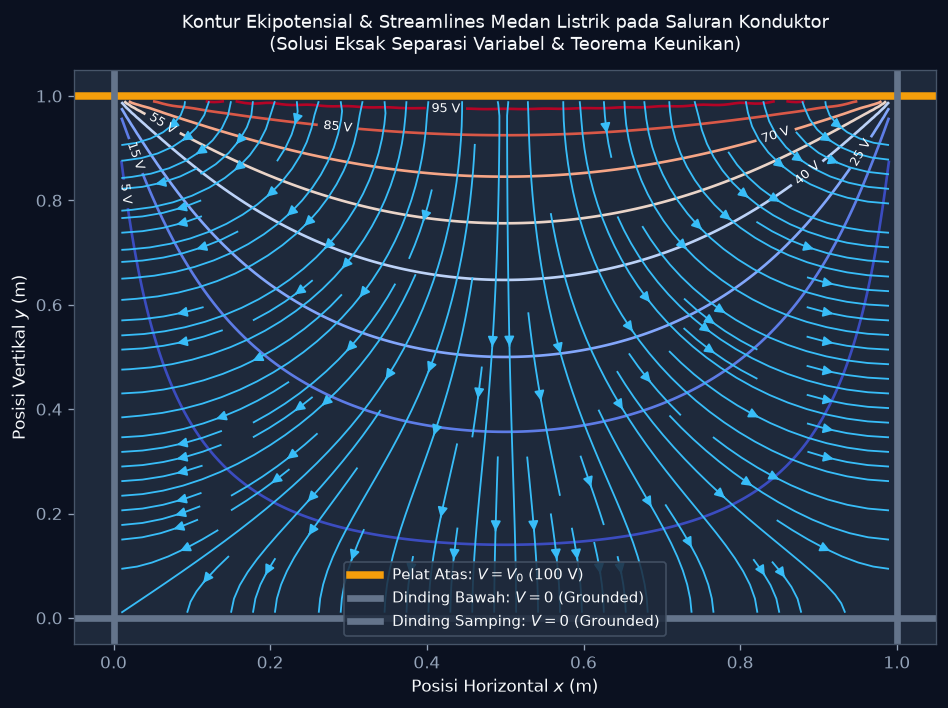

In [13]:
# Diagram Proyeksi Vektor 2D: Saluran Konduktor Persegi Panjang (Syarat Batas Dirichlet)
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

a_val, b_val = 1.0, 1.0
V0_val = 100.0

# Grid 2D di dalam saluran
x_grid = np.linspace(0.01, a_val - 0.01, 150)
y_grid = np.linspace(0.01, b_val - 0.01, 150)
X_m, Y_m = np.meshgrid(x_grid, y_grid)

# Superposisi Deret Fourier (25 suku ganjil)
V_2d = np.zeros_like(X_m)
Ex_2d = np.zeros_like(X_m)
Ey_2d = np.zeros_like(X_m)

for n in range(1, 41, 2):
    kn = n * np.pi / a_val
    cn = (4.0 * V0_val) / (n * np.pi * np.sinh(kn * b_val))
    V_term = cn * np.sin(kn * X_m) * np.sinh(kn * Y_m)
    V_2d += V_term
    Ex_2d -= cn * kn * np.cos(kn * X_m) * np.sinh(kn * Y_m)
    Ey_2d -= cn * kn * np.sin(kn * X_m) * np.cosh(kn * Y_m)

# Kontur Ekipotensial
levels = [5, 15, 25, 40, 55, 70, 85, 95]
cs = ax.contour(X_m, Y_m, V_2d, levels=levels, cmap='coolwarm', linewidths=1.6)
ax.clabel(cs, inline=True, fontsize=8, fmt='%1.0f V', colors='#f8fafc')

# Streamplot Medan Listrik E = -grad(V)
strm = ax.streamplot(x_grid, y_grid, Ex_2d, Ey_2d, color='#38bdf8', linewidth=1.1,
                     density=1.2, arrowsize=1.2)

# Gambar Dinding Batas Fisik Konduktor
ax.axhline(y=b_val, color='#f59e0b', linewidth=4.5, label='Pelat Atas: $V = V_0$ (100 V)')
ax.axhline(y=0, color='#64748b', linewidth=4.0, label='Dinding Bawah: $V = 0$ (Grounded)')
ax.axvline(x=0, color='#64748b', linewidth=4.0, label='Dinding Samping: $V = 0$ (Grounded)')
ax.axvline(x=a_val, color='#64748b', linewidth=4.0)

ax.set_title('Kontur Ekipotensial & Streamlines Medan Listrik pada Saluran Konduktor\n(Solusi Eksak Separasi Variabel & Teorema Keunikan)',
             fontsize=11, color='#f8fafc', pad=12)
ax.set_xlabel('Posisi Horizontal $x$ (m)', fontsize=10)
ax.set_ylabel('Posisi Vertikal $y$ (m)', fontsize=10)
ax.set_xlim(-0.05, a_val + 0.05)
ax.set_ylim(-0.05, b_val + 0.05)
ax.legend(loc='lower center', framealpha=0.85, facecolor='#1e293b', edgecolor='#475569', fontsize=9)
plt.tight_layout()
plt.show()


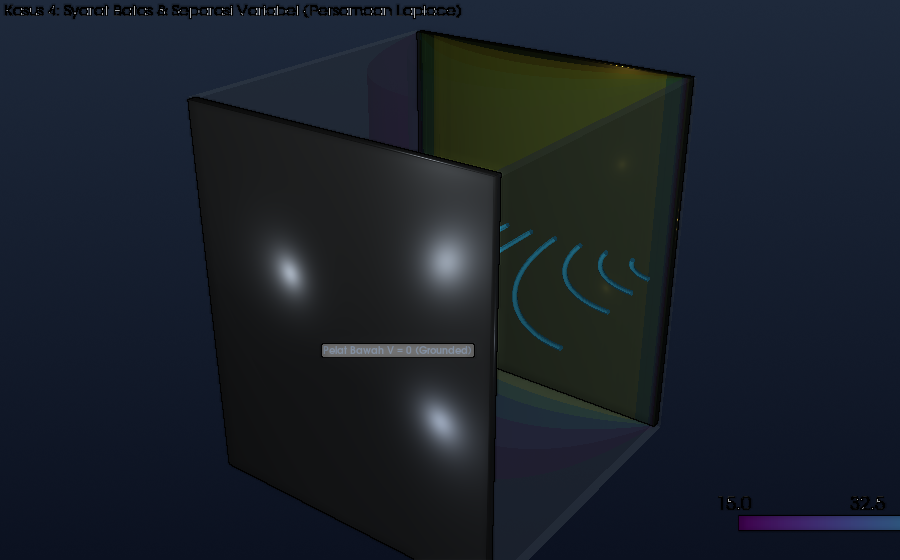

In [14]:
# Visualisasi 3D PyVista: Saluran Konduktor & Separasi Variabel Laplace 3D
p4 = init_pyvista_plotter("Kasus 4: Syarat Batas & Separasi Variabel (Persamaan Laplace)")

a_c, b_c, V0_c = 1.0, 1.0, 100.0

# 1. Grid 3D di dalam saluran
nx, ny, nz = 51, 51, 31
x_l = np.linspace(0.005, a_c - 0.005, nx)
y_l = np.linspace(0.005, b_c - 0.005, ny)
z_l = np.linspace(-0.6, 0.6, nz)
X3, Y3, Z3 = np.meshgrid(x_l, y_l, z_l, indexing='ij')

# Hitung V(x, y) melalui superposisi deret Fourier separasi variabel (15 suku ganjil)
V_3d = np.zeros_like(X3)
for n in range(1, 31, 2):
    kn = n * np.pi / a_c
    cn = (4.0 * V0_c / (n * np.pi * np.sinh(kn * b_c)))
    V_3d += cn * np.sin(kn * X3) * np.sinh(kn * Y3)

grid4 = pv.StructuredGrid(X3, Y3, Z3)
grid4['potential'] = V_3d.flatten(order='F')

# 2. Isosurfaces Ekipotensial 3D bertingkat di dalam saluran
iso_levels = [15.0, 30.0, 50.0, 70.0, 85.0]
isos4 = grid4.contour(isosurfaces=iso_levels, scalars='potential')
p4.add_mesh(isos4, cmap='viridis', opacity=0.45, show_scalar_bar=True,
            scalar_bar_args={'title': 'Potensial V (Volt)', 'color': '#f8fafc', 'position_x': 0.82})

# 3. Dinding-dinding Konduktor Fisik (Syarat Batas Dirichlet)
# Pelat Atas (y = b, V = V0) - Emas Berkilau PBR
top_plate = pv.Cube(center=(a_c/2, b_c, 0), x_length=a_c, y_length=0.03, z_length=1.2)
p4.add_mesh(top_plate, color='#f59e0b', pbr=True, metallic=0.9, roughness=0.15)
p4.add_point_labels([np.array([a_c/2, b_c + 0.06, 0])], [f"Pelat Atas V = V₀ ({V0_c:.0f} V)"], font_size=10, text_color='#f59e0b')

# Pelat Bawah (y = 0, V = 0 Grounded) - Logam Slate Gray
bot_plate = pv.Cube(center=(a_c/2, 0, 0), x_length=a_c, y_length=0.03, z_length=1.2)
p4.add_mesh(bot_plate, color='#64748b', pbr=True, metallic=0.7, roughness=0.3)
p4.add_point_labels([np.array([a_c/2, -0.06, 0])], ["Pelat Bawah V = 0 (Grounded)"], font_size=10, text_color='#94a3b8')

# Dinding Kiri (x = 0, V = 0) dan Kanan (x = a, V = 0)
left_wall = pv.Cube(center=(0, b_c/2, 0), x_length=0.03, y_length=b_c, z_length=1.2)
right_wall = pv.Cube(center=(a_c, b_c/2, 0), x_length=0.03, y_length=b_c, z_length=1.2)
p4.add_mesh(left_wall, color='#475569', opacity=0.35)
p4.add_mesh(right_wall, color='#475569', opacity=0.35)

# 4. Streamlines Garis Gaya Medan Listrik E = -grad(V)
seed_xs = np.linspace(0.12*a_c, 0.88*a_c, 9)
for xs in seed_xs:
    pts = [[xs, b_c - 0.04, 0.0]]
    cur = np.array([xs, b_c - 0.04, 0.0])
    for _ in range(120):
        Ex, Ey = 0.0, 0.0
        for n in range(1, 25, 2):
            kn = n * np.pi / a_c
            cn = (4.0 * V0_c / (n * np.pi * np.sinh(kn * b_c)))
            Ex -= cn * kn * np.cos(kn * cur[0]) * np.sinh(kn * cur[1])
            Ey -= cn * kn * np.sin(kn * cur[0]) * np.cosh(kn * cur[1])
        E_vec = np.array([Ex, Ey, 0.0])
        norm = np.linalg.norm(E_vec)
        if norm < 1e-4:
            break
        cur = cur + 0.015 * (E_vec / norm)
        pts.append(cur.copy())
        if cur[1] <= 0.02 or cur[0] <= 0.02 or cur[0] >= a_c - 0.02:
            break
    if len(pts) > 2:
        tube = pv.Spline(np.array(pts), 50).tube(radius=0.008)
        p4.add_mesh(tube, color='#38bdf8', opacity=0.85)

p4.camera_position = [(2.2, -1.8, 1.4), (a_c/2, b_c/2, 0), (0, 0, 1)]
p4.show()
p4.close()


---
## 6. Kasus Analitik 5: Bahan Dielektrik, Polarisasi, dan Kapasitansi

### 6.1 Penurunan Matematis Eksak
Ketika medan listrik $\mathbf{E}$ diterapkan pada material isolator (dielektrik), dipol-dipol mikroskopis mengalami pergeseran yang menghasilkan **Vektor Polarisasi** $\mathbf{P} = d\mathbf{p}/d\tau$. Polarisasi memunculkan **muatan terikat** (*bound charges*):
$$\rho_b = -\nabla \cdot \mathbf{P}, \quad \sigma_b = \mathbf{P} \cdot \hat{\mathbf{n}}$$

Vektor pergeseran listrik $\mathbf{D}$:
$$\mathbf{D} \equiv \epsilon_0 \mathbf{E} + \mathbf{P} = \epsilon_r \epsilon_0 \mathbf{E} \implies \nabla \cdot \mathbf{D} = \rho_f \iff \oint_{\mathcal{S}} \mathbf{D} \cdot d\mathbf{a} = Q_{f,\text{enc}}$$

#### Sistem Kapasitor Silinder Koaksial dengan Lapisan Dielektrik
Kapasitansi silinder koaksial berpanjang $L$, radius dalam $a$, radius luar $b$, dan permitivitas relatif $\epsilon_r$:
$$C = \frac{2\pi \epsilon_r \epsilon_0 L}{\ln(b/a)}$$
Energi yang tersimpan di dalam kapasitor:
$$U = \frac{1}{2} C (\Delta V)^2 = \frac{1}{2} \int \mathbf{D} \cdot \mathbf{E} d\tau = \frac{\pi \epsilon_r \epsilon_0 L (\Delta V)^2}{\ln(b/a)}$$

### 6.2 Penjelasan Fisis Muatan Terikat (*Bound Charges*)
Pada batas dielektrik di $s = a$, muatan terikat negatif $\sigma_b(a) = -\frac{\epsilon_r - 1}{\epsilon_r} \frac{\lambda_f}{2\pi a}$ sebagian menetralkan muatan bebas positif $+Q$ pada konduktor dalam, sehingga melemahkan medan listrik $\mathbf{E}$ di dalam rongga dan menurunkan beda potensial $\Delta V$. Akibatnya, kapasitas penyimpanan muatan ($C = Q/\Delta V$) meningkat pesat.

### 6.3 Formulasi Persamaan Superposisi: Polarisasi Makroskopis & Kapasitor Majemuk
1. **Superposisi Medan di Dalam Bahan Dielektrik:**
   Medan listrik total $\mathbf{E}$ di setiap titik di dalam bahan dielektrik merupakan **superposisi vektor** antara medan luar yang bersumber dari muatan bebas $\mathbf{E}_0$ dan medan polarisasi $\mathbf{E}_{\text{pol}}$ yang bersumber dari muatan terikat:
   $$\mathbf{E}(\mathbf{r}) = \mathbf{E}_0(\mathbf{r}) + \mathbf{E}_{\text{pol}}(\mathbf{r})$$
   Karena orientasi dipol terinduksi berlawanan dengan medan penggerak luar, medan polarisasi mereduksi medan awal sebesar faktor permitivitas relatif:
   $$\mathbf{E}(\mathbf{r}) = \mathbf{E}_0(\mathbf{r}) - \frac{\mathbf{P}(\mathbf{r})}{\epsilon_0} = \frac{\mathbf{E}_0(\mathbf{r})}{\epsilon_r}$$

2. **Superposisi Volume Momen Dipol Molekuler:**
   Secara mikroskopis, vektor polarisasi makroskopis $\mathbf{P}$ adalah superposisi volume rata-rata dari momen dipol molekuler individual $\mathbf{p}_i$:
   $$\mathbf{P}(\mathbf{r}) = \lim_{\Delta \tau \to 0} \frac{1}{\Delta \tau} \sum_{i \in \Delta \tau} \mathbf{p}_i = n \langle \mathbf{p} \rangle$$

3. **Superposisi Beda Potensial pada Kapasitansi Majemuk (Dielektrik Berlapis Seri):**
   Jika ruang antar-elektroda diisi oleh $N$ lapisan dielektrik konsentris berbeda dengan konstanta $\epsilon_{r1}, \epsilon_{r2}, \dots$, berdasarkan sifat integral garis potensial, beda potensial total antar-pelat adalah **superposisi linear dari beda potensial masing-masing lapisan**:
   $$\Delta V_{\text{total}} = \sum_{k=1}^N \Delta V_k = \sum_{k=1}^N \int_{s_k}^{s_{k+1}} \frac{\lambda_f}{2\pi \epsilon_{rk} \epsilon_0 s} ds = \frac{\lambda_f}{2\pi\epsilon_0} \sum_{k=1}^N \frac{1}{\epsilon_{rk}} \ln\left(\frac{s_{k+1}}{s_k}\right)$$
   Karena muatan bebas yang dilingkupi bernilai sama untuk setiap lapisan, superposisi beda potensial ini secara langsung menurunkan hukum superposisi kebalikan kapasitansi seri:
   $$\frac{1}{C_{\text{total}}} = \frac{\Delta V_{\text{total}}}{Q} = \sum_{k=1}^N \frac{\Delta V_k}{Q} = \sum_{k=1}^N \frac{1}{C_k}$$


In [15]:
# Verifikasi Simbolik SymPy: Kapasitansi Silinder Koaksial Berdielektrik
a_s, b_s, eps_r_s, L_s, lam_f_s, s_v = sp.symbols('a b epsilon_r L lambda_f s', positive=True, real=True)

# 1. Medan listrik di dalam dielektrik E(s)
E_diel = lam_f_s / (2 * sp.pi * eps0_sym * eps_r_s * s_v)

# 2. Beda potensial Delta V
Delta_V = sp.integrate(E_diel, (s_v, a_s, b_s))

# 3. Kapasitansi total C = Q_f / Delta_V
Q_f_sym = lam_f_s * L_s
C_sym = sp.simplify(Q_f_sym / Delta_V)

# 4. Rapat muatan terikat di batas s = a
P_s = (eps_r_s - 1) * eps0_sym * E_diel
sigma_b_a = -P_s.subs(s_v, a_s)  # n_hat mengarah ke pusat konduktor

print("=== VERIFIKASI SIMBOLIK SYMPY: KAPASITANSI DIELEKTRIK ===")
print(f"Medan Listrik di dalam Dielektrik E(s) = {E_diel}")
print(f"Beda Potensial Antar-Elektroda Delta V  = {Delta_V}")
print(f"Kapasitansi Silinder Koaksial C       = {C_sym}")
print(f"Rapat Muatan Terikat di Antarmuka s=a  = {sigma_b_a}")
print(f"Peningkatan Kapasitansi akibat Dielektrik: Faktor epsilon_r = {eps_r_s}x")
assert sp.simplify(C_sym - (2 * sp.pi * eps0_sym * eps_r_s * L_s) / sp.log(b_s / a_s)) == 0, "Kapasitansi tidak sesuai analitik!"
print("Verifikasi Kapasitansi Dielektrik: SUKSES SEMPURNA")


=== VERIFIKASI SIMBOLIK SYMPY: KAPASITANSI DIELEKTRIK ===
Medan Listrik di dalam Dielektrik E(s) = lambda_f/(2*pi*epsilon_0*epsilon_r*s)
Beda Potensial Antar-Elektroda Delta V  = -lambda_f*log(a)/(2*pi*epsilon_0*epsilon_r) + lambda_f*log(b)/(2*pi*epsilon_0*epsilon_r)
Kapasitansi Silinder Koaksial C       = -2*pi*L*epsilon_0*epsilon_r/log(a/b)
Rapat Muatan Terikat di Antarmuka s=a  = -lambda_f*(epsilon_r - 1)/(2*pi*a*epsilon_r)
Peningkatan Kapasitansi akibat Dielektrik: Faktor epsilon_r = epsilon_rx
Verifikasi Kapasitansi Dielektrik: SUKSES SEMPURNA


<string>:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


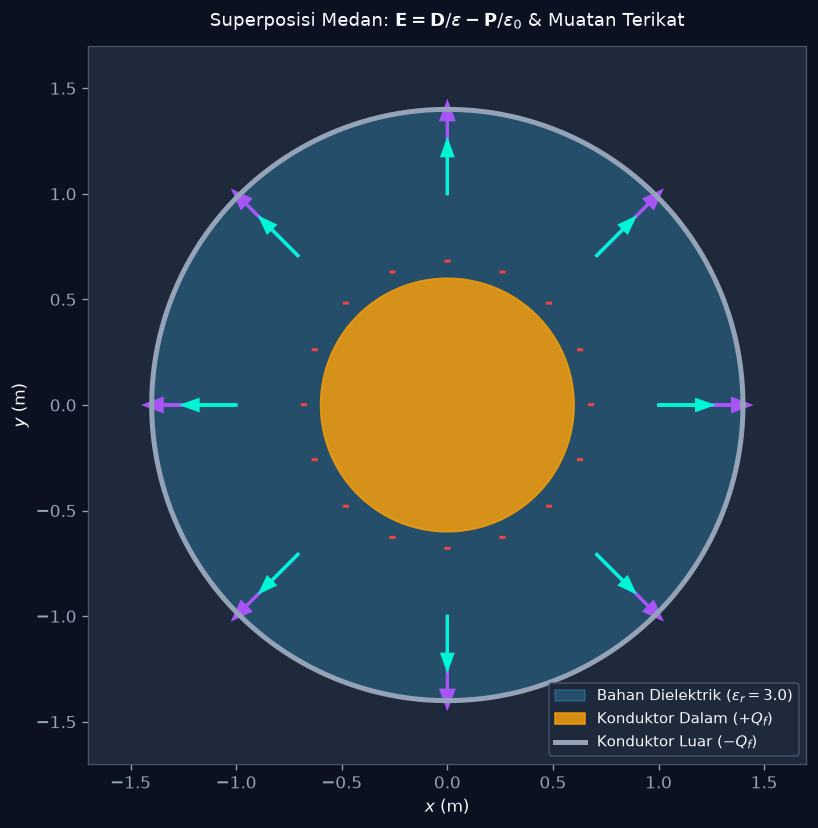

In [16]:
# Diagram Proyeksi Vektor 2D: Distribusi Vektor D, E, dan Muatan Terikat
fig, ax = plt.subplots(figsize=(7, 7), dpi=120)

a_val = 0.6
b_val = 1.4

th_c = np.linspace(0, 2*np.pi, 200)

# Lapisan Dielektrik
ax.fill(b_val*np.cos(th_c), b_val*np.sin(th_c), color='#38bdf8', alpha=0.25, label='Bahan Dielektrik ($\\epsilon_r = 3.0$)')
# Konduktor Dalam (+Q)
ax.fill(a_val*np.cos(th_c), a_val*np.sin(th_c), color='#f59e0b', alpha=0.85, label='Konduktor Dalam ($+Q_f$)')
# Konduktor Luar (-Q)
ax.plot(b_val*np.cos(th_c), b_val*np.sin(th_c), color='#94a3b8', lw=3.0, label='Konduktor Luar ($-Q_f$)')

# Vektor D, E, dan P
for th in np.linspace(0, 2*np.pi, 8, endpoint=False):
    s_mid = 1.0
    # Vektor D (Perpindahan Listrik) - Ungu
    ax.arrow(s_mid*np.cos(th), s_mid*np.sin(th), 0.35*np.cos(th), 0.35*np.sin(th),
             head_width=0.06, head_length=0.08, fc='#a855f7', ec='#a855f7', lw=1.8)
    # Vektor E (Medan Listrik Tereduksi) - Cyan
    ax.arrow(s_mid*np.cos(th), s_mid*np.sin(th), 0.18*np.cos(th), 0.18*np.sin(th),
             head_width=0.05, head_length=0.07, fc='#00f5d4', ec='#00f5d4', lw=1.8)

# Muatan terikat di antarmuka s = a
for th in np.linspace(0, 2*np.pi, 16, endpoint=False):
    ax.text((a_val + 0.08)*np.cos(th), (a_val + 0.08)*np.sin(th), '-',
            color='#ef4444', fontsize=12, fontweight='bold', ha='center', va='center')

ax.set_aspect('equal')
ax.set_title('Superposisi Medan: $\\mathbf{E} = \\mathbf{D}/\\epsilon - \\mathbf{P}/\\epsilon_0$ & Muatan Terikat',
             fontsize=11, color='#f8fafc', pad=12)
ax.set_xlabel('$x$ (m)', fontsize=10)
ax.set_ylabel('$y$ (m)', fontsize=10)
ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-1.7, 1.7)
ax.legend(loc='lower right', framealpha=0.85, facecolor='#1e293b', edgecolor='#475569', fontsize=9)
plt.tight_layout()
plt.show()


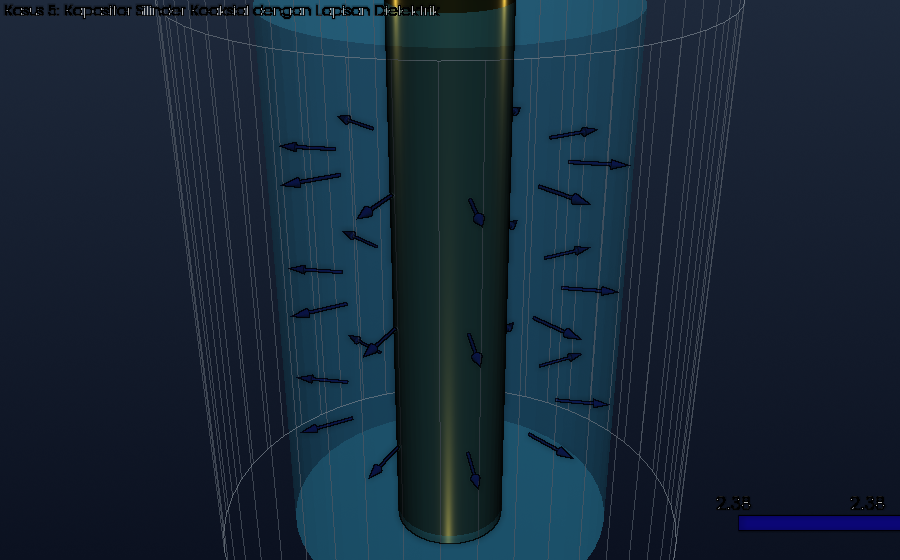

In [17]:
# Visualisasi 3D PyVista: Kapasitor Silinder Koaksial Berdielektrik Realistik
p5 = init_pyvista_plotter("Kasus 5: Kapasitor Silinder Koaksial dengan Lapisan Dielektrik")

L_cap = 2.2
a = 0.22
b = 0.65
c = 0.95

# 1. Silinder Konduktor Dalam (+Q) - Tembaga Berkilau
cyl_inner = pv.Cylinder(center=(0, 0, 0), direction=(0, 0, 1), radius=a, height=L_cap, resolution=50)
p5.add_mesh(cyl_inner, color='#f59e0b', pbr=True, metallic=0.9, roughness=0.18)

# 2. Lapisan Dielektrik (Translucent Cyan Crystal)
cyl_diel = pv.Cylinder(center=(0, 0, 0), direction=(0, 0, 1), radius=b, height=L_cap*0.96, resolution=50)
p5.add_mesh(cyl_diel, color='#38bdf8', opacity=0.32)

# 3. Silinder Konduktor Luar (-Q) - Wireframe Logam Perak
cyl_outer = pv.Cylinder(center=(0, 0, 0), direction=(0, 0, 1), radius=c, height=L_cap, resolution=50)
p5.add_mesh(cyl_outer, color='#94a3b8', style='wireframe', line_width=1.2, opacity=0.45)

# 4. Vektor medan pergeseran listrik D terdistribusi radial
z_evals = [-0.5, 0.0, 0.5]
r_evals = [0.42]
thetas = np.linspace(0, 2*np.pi, 10, endpoint=False)

starts, dirs, d_mags = [], [], []
for z_o in z_evals:
    for r_o in r_evals:
        for th in thetas:
            starts.append([r_o*np.cos(th), r_o*np.sin(th), z_o])
            dirs.append([np.cos(th), np.sin(th), 0.0])
            d_mags.append(1.0 / r_o)

poly = pv.PolyData(np.array(starts))
poly['vectors'] = np.array(dirs)
poly['|D|'] = np.array(d_mags)
arrows = poly.glyph(orient='vectors', scale=False, factor=0.22,
                    geom=pv.Arrow(shaft_radius=0.035, tip_radius=0.09, tip_length=0.32))
p5.add_mesh(arrows, cmap='plasma', scalars='|D|', show_scalar_bar=True,
            scalar_bar_args={'title': '|D| (C/m²)', 'color': '#f8fafc', 'position_x': 0.82})

p5.camera_position = [(2.5, -2.5, 1.8), (0, 0, 0), (0, 0, 1)]
p5.show()
p5.close()


---
## 7. Rangkuman Komparatif & Kesimpulan Akhir

| No | Topik / Kasus Analitik | Prinsip & Hukum Pokok | Karakteristik Medan $\mathbf{E}$ | Potensial Skalar $V(\mathbf{r})$ | Manifestasi Persamaan Superposisi |
| :---: | :--- | :--- | :--- | :--- | :--- |
| **1** | **Gaya Listrik & Hukum Coulomb** | Superposisi linier & integrasi $dq'$ | $E_s = \frac{\lambda L}{4\pi\epsilon_0 s \sqrt{s^2 + L^2/4}}$, $E_z = 0$ | $V(s) = \frac{\lambda}{2\pi\epsilon_0}\ln(s_0/s)$ $(L \to \infty)$ | $\mathbf{E} = \int d\mathbf{E}$. Superposisi pasangan elemen simetris $\pm z'$: $dE_z$ saling meniadakan, $dE_s$ saling menguatkan. |
| **2** | **Medan Listrik & Hukum Gauss** | Fluks permukaan tertutup $\oint \mathbf{E}\cdot d\mathbf{a} = \frac{Q_{\text{enc}}}{\epsilon_0}$ | Di dalam: $E \propto r$ (linear)<br>Di luar: $E \propto 1/r^2$ (Newtonian) | $V_{\text{in}}(r) = \frac{Q}{8\pi\epsilon_0 R}(3 - r^2/R^2)$<br>$V_{\text{out}}(r) = \frac{Q}{4\pi\epsilon_0 r}$ | Superposisi kulit bola $\mathbf{E} = \int d\mathbf{E}_{\text{kulit}}$. Superposisi rongga eksentrik: $\mathbf{E}_{\text{rongga}} = \frac{\rho_0}{3\epsilon_0}\mathbf{d}$ (homogen). |
| **3** | **Potensial & Persamaan Laplace** | $\mathbf{E} = -\nabla V$, $\nabla^2 V = 0$ (ruang bebas) | Ortogonal terhadap permukaan ekipotensial | Memenuhi teorema nilai rata-rata, tidak ada ekstrem lokal di vakum | $V = \sum V_i$ (superposisi skalar linear). Energi bersifat non-linear: $W = W_1 + W_2 + \epsilon_0\int \mathbf{E}_1\cdot\mathbf{E}_2 d\tau$. |
| **4** | **Syarat Batas & Separasi Variabel** | Teorema Keunikan Dirichlet & Neumann, Laplace $\nabla^2 V = 0$ | $\mathbf{E}$ menumbuk tegak lurus konduktor ($E_\parallel = 0$) | Solusi deret Fourier eksak: $V(x,y) = \frac{4V_0}{\pi}\sum \frac{1}{n}\sin(k_n x)\frac{\sinh(k_n y)}{\sinh(k_n b)}$ | Superposisi tak hingga deret moda ortogonal $\sum C_n X_n Y_n$. Teorema keunikan menjamin solusi superposisi ini adalah satu-satunya solusi fisika yang eksis. |
| **5** | **Bahan Dielektrik & Kapasitansi** | Polarisasi $\mathbf{P}$, Vektor $\mathbf{D} = \epsilon_r\epsilon_0\mathbf{E}$ | Medan $\mathbf{E}$ melemah sebesar $1/\epsilon_r$, medan $\mathbf{D}$ invarian terhadap medium | $\Delta V = \frac{\lambda_f}{2\pi\epsilon_r\epsilon_0}\ln(b/a)$ | $\mathbf{E} = \mathbf{E}_0 + \mathbf{E}_{\text{pol}}$. Superposisi beda potensial seri: $\Delta V = \sum \Delta V_k \implies 1/C_{\text{total}} = \sum 1/C_k$. |

### Kesimpulan Fisis & Relevansi Elektrodinamika Lanjut
1. **Unifikasi Elektrostatika & Universalitas Superposisi:** Seluruh fenomena elektrostatik berakar pada linearitas persamaan Maxwell statik. Persamaan superposisi menjembatani hukum-hukum fundamental: dari interaksi gaya mikroskopis Coulomb menuju medan terdistribusi Gauss, masalah nilai batas konduktor, hingga respon polarisasi materi dielektrik.
2. **Kekuatan Teorema Keunikan:** Persamaan diferensial parsial eliptik Laplace $\nabla^2 V = 0$ menjamin bahwa jika solusi yang dibangun melalui superposisi memenuhi syarat batas fisik yang ditentukan, maka solusi tersebut adalah satu-satunya solusi yang eksis di alam semesta.
3. **Jembatan Menuju Elektrodinamika Relativistik:** Dalam kerangka teori relativitas khusus Einstein, medan elektrostatik $\mathbf{E}$ dan medan magnetostatik $\mathbf{B}$ menyatu ke dalam **Tensor Kuat Medan Elektromagnetik 4-Dimensi** $F^{\mu\nu}$:
   $$F^{\mu\nu} = \partial^\mu A^\nu - \partial^\nu A^\mu = \begin{pmatrix} 0 & -E_x/c & -E_y/c & -E_z/c \\ E_x/c & 0 & -B_z & B_y \\ E_y/c & B_z & 0 & -B_x \\ E_z/c & -B_y & B_x & 0 \end{pmatrix}$$
   di mana potensial elektrostatik $V$ berkombinasi dengan potensial vektor magnetik $\mathbf{A}$ membentuk **Empat-Potensial Relativistik** $A^\mu = (V/c, \mathbf{A})$. Transformasi Lorentz memperlihatkan bahwa medan listrik murni dalam suatu kerangka acuan diam akan termanifestasi sebagai kombinasi medan listrik dan medan magnet bagi pengamat yang bergerak.
